In [1]:
import pandas as pd
import numpy as np
import subprocess
import os
from datetime import datetime, timedelta, time, date
import datetime
from datetime import datetime
import locale
import seaborn as sns
import matplotlib.pyplot as plt
import unicodedata
import re

Paraderos

In [2]:
#importar paradas

paradas = pd.read_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/Paraderos_Zonales_del_SITP.csv')

paradas.head(3)

,X,Y,objectid,cenefa,zona_sitp,nombre,via,direccion_bandera,localidad,longitud,latitud,consecutivo_zona,tipo_m_s,consola,panel,audio,zonas_nuevas,globalid,shape
0,1.001502e+06,1.010205e+06,1,001A00,00,C.C. Iserra 100,AC 100,AC 100 - KR 54,Barrios Unidos,-74.063971,4.688481,001,M,AC 100 - KR 54 (001A00),AC 100 - KR 54,Avenida Calle 100 Carrera 54,C,{1C0DBC4E-15BC-4BBE-BC16-5628077DBE2E},NaN
1,1.003505e+06,1.009719e+06,2,001A01,01,Br. Rincón del Chicó,AC 100,AC 100 - KR 13,Usaquén,-74.045914,4.684091,001,M,AC 100 - KR 13 (001A01),AC 100 - KR 13,Avenida Calle 100 Carrera 13,B,{60A22A44-AD56-4DF4-A3E6-6830B9FB0792},NaN
2,1.001238e+06,1.018098e+06,3,001A02,02,Gimnasio Iragua,AV. Boyacá,AV. Boyacá - AC 170,Suba,-74.066350,4.759867,001,S,AV. Boyacá - AC 170 (001A02),AV. Boyacá - AC 170,Avenida Boyacá Avenida Calle 170,C,{97155274-E4D5-45A4-891F-2DCA19FF10D9},NaN


ICO vencido

In [3]:
ico = pd.read_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/ICO/Control Transmitools.csv', encoding='latin', sep=';')

ico.head(3)

,ï»¿ID GMOVIL,ID Novedad TMSA,Consecutivo interventorÃ­a,Componente,Fecha identificaciÃ³n,Fecha de notificaciÃ³n,CÃ³d. InfracciÃ³n TMSA,DescripciÃ³n,puntos,Cod. Operador,Movil,Ruta,DESCRIPCIÃN DE NOVEDAD,Evidencias,Ãrea,Patio,AÃ±o,Mes
0,71653704.0,7192021,NaN,Operaciones,15/10/2016,16/10/2019,I6016-1,Abandono del vehÃ­culo por parte del concesion...,15,NaN,Z50-2078,614,El zonal se encuentra abandonado en cabecera d...,4,Operaciones,VERBENA,2016,octubre
1,71653705.0,7192076,NaN,Operaciones,15/10/2016,16/10/2019,I6016-1,Abandono del vehÃ­culo por parte del concesion...,15,NaN,Z52-4006,614,El zonal se encuentra abandonado en cabecera d...,4,Operaciones,TINTAL 2,2016,octubre
2,71653706.0,7192026,NaN,Operaciones,15/10/2016,16/10/2019,I6016-1,Abandono del vehÃ­culo por parte del concesion...,15,NaN,Z50-4191,614,El zonal se encuentra abandonado en cabecera d...,4,Operaciones,TINTAL 2,2016,octubre


In [4]:
ico = ico[ico["AÃ±o"].isin([2025, 2026])]

In [5]:
def limpiar_columnas(col):
    
    col = col.encode('latin1').decode('utf8', errors='ignore')  # corregir codificación
    
    col = unicodedata.normalize('NFKD', col) \
          .encode('ascii', 'ignore') \
          .decode('utf-8')  # quitar tildes
    
    col = col.replace('.', '') \
             .replace(' ', '_') \
             .replace('-', '_')
    
    return col.upper()

ico.columns = [limpiar_columnas(c) for c in ico.columns]

ico.head(3)

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,MOVIL,RUTA,DESCRIPCION_DE_NOVEDAD,EVIDENCIAS_,AREA,PATIO,ANO,MES
18715,7.166176e+10,1476378,7497915.0,Int. Seguridad,1/01/2025,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,Z50-4522,577,01/01/2025/ 09:14/ Ruta577/Tabla8/Calle 38C Su...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,VERBENA,2025,enero
18716,7.166176e+10,1476397,7497920.0,Int. Seguridad,1/01/2025,3/01/2025,I6019-1,No portar el cinturÃ³n de seguridad o usuarlo ...,15,507967,Z50-4525,P500,01/01/2025/ 12:18/ RutaP500/Tabla3/Carrera 11 ...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,LA Y,2025,enero
18717,7.166176e+10,1476391,7497925.0,Int. Operaciones,1/01/2025,3/01/2025,I5023-3,No cumplir con los lineamientos establecidos e...,10,509117,Z50-4131,DH209,01/01/2025/ 14:46/ RutaDH209/Tabla1/Av. Ciudad...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TINTAL,2025,enero


In [6]:
def extraer_direccion(texto):
    
    if pd.isna(texto):
        return None
    
    partes = [p.strip() for p in texto.split("/")]

    for i, p in enumerate(partes):
        if "tabla" in p.lower():
            if i + 1 < len(partes):
                return partes[i+1]
    
    return None


ico["DIRECCION_EXTRAIDA"]  = ico["DESCRIPCION_DE_NOVEDAD"].apply(extraer_direccion)

ico.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,MOVIL,RUTA,DESCRIPCION_DE_NOVEDAD,EVIDENCIAS_,AREA,PATIO,ANO,MES,DIRECCION_EXTRAIDA
18715,7.166176e+10,1476378,7497915.0,Int. Seguridad,1/01/2025,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,Z50-4522,577,01/01/2025/ 09:14/ Ruta577/Tabla8/Calle 38C Su...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,VERBENA,2025,enero,Calle 38C Sur con Carrera 79
18716,7.166176e+10,1476397,7497920.0,Int. Seguridad,1/01/2025,3/01/2025,I6019-1,No portar el cinturÃ³n de seguridad o usuarlo ...,15,507967,Z50-4525,P500,01/01/2025/ 12:18/ RutaP500/Tabla3/Carrera 11 ...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,LA Y,2025,enero,Carrera 11 con Calle 73
18717,7.166176e+10,1476391,7497925.0,Int. Operaciones,1/01/2025,3/01/2025,I5023-3,No cumplir con los lineamientos establecidos e...,10,509117,Z50-4131,DH209,01/01/2025/ 14:46/ RutaDH209/Tabla1/Av. Ciudad...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TINTAL,2025,enero,Av. Ciudad de Cali con Calle 15A
18718,7.166176e+10,1476736,12919.0,Int. Operaciones,1/01/2025,3/01/2025,M0021,No cumplir con los lineamientos u obligaciones...,1,504318,E0745,M86-K86,01-ene-2025 18:27/MÃ³vil E0745/Ruta K86/Tabla ...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TRONCAL,2025,enero,A la altura de la Parada Muelle Internacional ...
18719,7.166176e+10,1476407,7497926.0,Int. Seguridad,1/01/2025,3/01/2025,I6012,"Manipular, tener a la mano o usar equipos elec...",10,508894,Z50-4379,740,01/01/2025/ 15:40/ Ruta740/Tabla7/Calle 26 Sur...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,VERBENA,2025,enero,Calle 26 Sur con Carrera 78B


In [7]:
patron_direccion = re.compile(
    r"(calle|carrera|transversal|avenida|diagonal|portal|parada|altura|Av.|Ciudad|ciudad|Escuela|escuela|Corferias|Salitre|salitre|corferias|Salitre|Biblioteca|Polo|Campiña|Bicentenario|San|Guatoque|agosto|Agosto|san|Quirigua|Humedal|Normandía|Gobernación|Policarpa|Museo|museo|Country|country|Puente|puente|Tiempo|tiempo|Aeropuerto|Patio|Estación |Avenida )",
    re.IGNORECASE
)

def extraer_direccion(texto):

    if pd.isna(texto):
        return None

    partes = [p.strip() for p in texto.split("/")]

    for p in partes:
        if patron_direccion.search(p):
            return p

    return None


ico["DIRECCION_EXTRAIDA_R"] = ico["DESCRIPCION_DE_NOVEDAD"].apply(extraer_direccion)

ico.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,MOVIL,RUTA,DESCRIPCION_DE_NOVEDAD,EVIDENCIAS_,AREA,PATIO,ANO,MES,DIRECCION_EXTRAIDA,DIRECCION_EXTRAIDA_R
18715,7.166176e+10,1476378,7497915.0,Int. Seguridad,1/01/2025,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,Z50-4522,577,01/01/2025/ 09:14/ Ruta577/Tabla8/Calle 38C Su...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,VERBENA,2025,enero,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79
18716,7.166176e+10,1476397,7497920.0,Int. Seguridad,1/01/2025,3/01/2025,I6019-1,No portar el cinturÃ³n de seguridad o usuarlo ...,15,507967,Z50-4525,P500,01/01/2025/ 12:18/ RutaP500/Tabla3/Carrera 11 ...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,LA Y,2025,enero,Carrera 11 con Calle 73,Carrera 11 con Calle 73
18717,7.166176e+10,1476391,7497925.0,Int. Operaciones,1/01/2025,3/01/2025,I5023-3,No cumplir con los lineamientos establecidos e...,10,509117,Z50-4131,DH209,01/01/2025/ 14:46/ RutaDH209/Tabla1/Av. Ciudad...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TINTAL,2025,enero,Av. Ciudad de Cali con Calle 15A,Av. Ciudad de Cali con Calle 15A
18718,7.166176e+10,1476736,12919.0,Int. Operaciones,1/01/2025,3/01/2025,M0021,No cumplir con los lineamientos u obligaciones...,1,504318,E0745,M86-K86,01-ene-2025 18:27/MÃ³vil E0745/Ruta K86/Tabla ...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TRONCAL,2025,enero,A la altura de la Parada Muelle Internacional ...,A la altura de la Parada Muelle Internacional ...
18719,7.166176e+10,1476407,7497926.0,Int. Seguridad,1/01/2025,3/01/2025,I6012,"Manipular, tener a la mano o usar equipos elec...",10,508894,Z50-4379,740,01/01/2025/ 15:40/ Ruta740/Tabla7/Calle 26 Sur...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,VERBENA,2025,enero,Calle 26 Sur con Carrera 78B,Calle 26 Sur con Carrera 78B


In [8]:
def limpiar_direccion(texto):

    if pd.isna(texto):
        return None
    
    # corregir codificación
    texto = texto.encode("latin1", errors="ignore").decode("utf8", errors="ignore")

    # eliminar prefijos
    texto = re.sub(
        r'(?i)a la altura de la\s*|a la altura de\s*|direccion\s*|direcci[oó]n\s*:?\s*',
        '',
        texto
    )

    return texto.strip()


ico["DIRECCION_LIMPIA"] = ico["DIRECCION_EXTRAIDA_R"].apply(limpiar_direccion)

ico.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,RUTA,DESCRIPCION_DE_NOVEDAD,EVIDENCIAS_,AREA,PATIO,ANO,MES,DIRECCION_EXTRAIDA,DIRECCION_EXTRAIDA_R,DIRECCION_LIMPIA
18715,7.166176e+10,1476378,7497915.0,Int. Seguridad,1/01/2025,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,577,01/01/2025/ 09:14/ Ruta577/Tabla8/Calle 38C Su...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,VERBENA,2025,enero,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79
18716,7.166176e+10,1476397,7497920.0,Int. Seguridad,1/01/2025,3/01/2025,I6019-1,No portar el cinturÃ³n de seguridad o usuarlo ...,15,507967,...,P500,01/01/2025/ 12:18/ RutaP500/Tabla3/Carrera 11 ...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,LA Y,2025,enero,Carrera 11 con Calle 73,Carrera 11 con Calle 73,Carrera 11 con Calle 73
18717,7.166176e+10,1476391,7497925.0,Int. Operaciones,1/01/2025,3/01/2025,I5023-3,No cumplir con los lineamientos establecidos e...,10,509117,...,DH209,01/01/2025/ 14:46/ RutaDH209/Tabla1/Av. Ciudad...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TINTAL,2025,enero,Av. Ciudad de Cali con Calle 15A,Av. Ciudad de Cali con Calle 15A,Av. Ciudad de Cali con Calle 15A
18718,7.166176e+10,1476736,12919.0,Int. Operaciones,1/01/2025,3/01/2025,M0021,No cumplir con los lineamientos u obligaciones...,1,504318,...,M86-K86,01-ene-2025 18:27/MÃ³vil E0745/Ruta K86/Tabla ...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TRONCAL,2025,enero,A la altura de la Parada Muelle Internacional ...,A la altura de la Parada Muelle Internacional ...,Parada Muelle Internacional (Aeropuerto)
18719,7.166176e+10,1476407,7497926.0,Int. Seguridad,1/01/2025,3/01/2025,I6012,"Manipular, tener a la mano o usar equipos elec...",10,508894,...,740,01/01/2025/ 15:40/ Ruta740/Tabla7/Calle 26 Sur...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,VERBENA,2025,enero,Calle 26 Sur con Carrera 78B,Calle 26 Sur con Carrera 78B,Calle 26 Sur con Carrera 78B


In [9]:
def limpiar_texto(texto):
    
    if pd.isna(texto):
        return texto
    
    # normalizar acentos
    texto = unicodedata.normalize('NFKD', texto)
    texto = texto.encode('ascii', 'ignore').decode('utf-8')
    
    return texto


ico["DIRECCION_LIMPIA"] = ico["DIRECCION_LIMPIA"].apply(limpiar_texto)

ico.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,RUTA,DESCRIPCION_DE_NOVEDAD,EVIDENCIAS_,AREA,PATIO,ANO,MES,DIRECCION_EXTRAIDA,DIRECCION_EXTRAIDA_R,DIRECCION_LIMPIA
18715,7.166176e+10,1476378,7497915.0,Int. Seguridad,1/01/2025,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,577,01/01/2025/ 09:14/ Ruta577/Tabla8/Calle 38C Su...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,VERBENA,2025,enero,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79
18716,7.166176e+10,1476397,7497920.0,Int. Seguridad,1/01/2025,3/01/2025,I6019-1,No portar el cinturÃ³n de seguridad o usuarlo ...,15,507967,...,P500,01/01/2025/ 12:18/ RutaP500/Tabla3/Carrera 11 ...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,LA Y,2025,enero,Carrera 11 con Calle 73,Carrera 11 con Calle 73,Carrera 11 con Calle 73
18717,7.166176e+10,1476391,7497925.0,Int. Operaciones,1/01/2025,3/01/2025,I5023-3,No cumplir con los lineamientos establecidos e...,10,509117,...,DH209,01/01/2025/ 14:46/ RutaDH209/Tabla1/Av. Ciudad...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TINTAL,2025,enero,Av. Ciudad de Cali con Calle 15A,Av. Ciudad de Cali con Calle 15A,Av. Ciudad de Cali con Calle 15A
18718,7.166176e+10,1476736,12919.0,Int. Operaciones,1/01/2025,3/01/2025,M0021,No cumplir con los lineamientos u obligaciones...,1,504318,...,M86-K86,01-ene-2025 18:27/MÃ³vil E0745/Ruta K86/Tabla ...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,TRONCAL,2025,enero,A la altura de la Parada Muelle Internacional ...,A la altura de la Parada Muelle Internacional ...,Parada Muelle Internacional (Aeropuerto)
18719,7.166176e+10,1476407,7497926.0,Int. Seguridad,1/01/2025,3/01/2025,I6012,"Manipular, tener a la mano o usar equipos elec...",10,508894,...,740,01/01/2025/ 15:40/ Ruta740/Tabla7/Calle 26 Sur...,http://transmitools.transmilenio.gov.co/bucket...,Operaciones,VERBENA,2025,enero,Calle 26 Sur con Carrera 78B,Calle 26 Sur con Carrera 78B,Calle 26 Sur con Carrera 78B


In [10]:
import re

ico["DIRECCION_LIMPIA"] = ico["DIRECCION_LIMPIA"].str.replace(
    r'(?i)^(parada|estacion|dirección|direccion|DirecciA3n)\s*',
    '',
    regex=True
)

In [11]:
patron_direccion = r'(?i)(calle|carrera|avenida|av|transversal|diagonal)'

ico = ico[
    ico["DIRECCION_LIMPIA"].str.contains(patron_direccion, na=False)
]

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_14484\2219601778.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ico["DIRECCION_LIMPIA"].str.contains(patron_direccion, na=False)


In [12]:

def normalizar_direccion(texto):

    if pd.isna(texto):
        return None

    texto = texto.upper()

    reemplazos = {
        "AVENIDA": "AV",
        "AV.": "AV",
        "CALLE": "CL",
        "CARRERA": "KR",
        "CON": "-",
    }

    for k, v in reemplazos.items():
        texto = texto.replace(k, v)

    texto = re.sub(r"\s+", " ", texto).strip()

    return texto

In [13]:
ico["DIR_NORM"] = ico["DIRECCION_LIMPIA"].apply(normalizar_direccion)

paradas["DIR_NORM"] = paradas["direccion_bandera"].apply(normalizar_direccion)

In [14]:
def clave_interseccion(texto):

    partes = re.split(r"-", texto)

    if len(partes) >= 2:
        a = partes[0].strip()
        b = partes[1].strip()

        # ordenar para evitar duplicados
        return " - ".join(sorted([a, b]))

    return texto

In [15]:
ico["CLAVE"] = ico["DIR_NORM"].apply(clave_interseccion)
paradas["CLAVE"] = paradas["DIR_NORM"].apply(clave_interseccion)

In [16]:
ico_geo = ico.merge(
    paradas[["CLAVE", "localidad", "longitud", "latitud"]],
    on="CLAVE",
    how="left"
)

ico_geo.head(2)

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,ANO,MES,DIRECCION_EXTRAIDA,DIRECCION_EXTRAIDA_R,DIRECCION_LIMPIA,DIR_NORM,CLAVE,localidad,longitud,latitud
0,7.166176e+10,1476378,7497915.0,Int. Seguridad,1/01/2025,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,2025,enero,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79,CL 38C SUR - KR 79,CL 38C SUR - KR 79,Kennedy,-74.156958,4.624148
1,7.166176e+10,1476378,7497915.0,Int. Seguridad,1/01/2025,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,2025,enero,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79,CL 38C SUR - KR 79,CL 38C SUR - KR 79,Kennedy,-74.156776,4.624149


Patrones

In [17]:
ico_geo["COD_OPERADOR"] = (
    ico_geo["COD_OPERADOR"]
    .astype(str)
    .str.replace("Ã‚Â", "", regex=False)
    .str.replace("Â", "", regex=False)
    .str.strip()
)

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,ANO,MES,DIRECCION_EXTRAIDA,DIRECCION_EXTRAIDA_R,DIRECCION_LIMPIA,DIR_NORM,CLAVE,localidad,longitud,latitud
0,7.166176e+10,1476378,7497915.0,Int. Seguridad,1/01/2025,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,2025,enero,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79,CL 38C SUR - KR 79,CL 38C SUR - KR 79,Kennedy,-74.156958,4.624148
1,7.166176e+10,1476378,7497915.0,Int. Seguridad,1/01/2025,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,2025,enero,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79,CL 38C SUR - KR 79,CL 38C SUR - KR 79,Kennedy,-74.156776,4.624149
2,7.166176e+10,1476397,7497920.0,Int. Seguridad,1/01/2025,3/01/2025,I6019-1,No portar el cinturÃ³n de seguridad o usuarlo ...,15,507967,...,2025,enero,Carrera 11 con Calle 73,Carrera 11 con Calle 73,Carrera 11 con Calle 73,KR 11 - CL 73,CL 73 - KR 11,NaN,NaN,NaN
3,7.166176e+10,1476391,7497925.0,Int. Operaciones,1/01/2025,3/01/2025,I5023-3,No cumplir con los lineamientos establecidos e...,10,509117,...,2025,enero,Av. Ciudad de Cali con Calle 15A,Av. Ciudad de Cali con Calle 15A,Av. Ciudad de Cali con Calle 15A,AV CIUDAD DE CALI - CL 15A,AV CIUDAD DE CALI - CL 15A,NaN,NaN,NaN
4,7.166176e+10,1476407,7497926.0,Int. Seguridad,1/01/2025,3/01/2025,I6012,"Manipular, tener a la mano o usar equipos elec...",10,508894,...,2025,enero,Calle 26 Sur con Carrera 78B,Calle 26 Sur con Carrera 78B,Calle 26 Sur con Carrera 78B,CL 26 SUR - KR 78B,CL 26 SUR - KR 78B,NaN,NaN,NaN


In [18]:
ico_geo["COD_OPERADOR"] = ico_geo["COD_OPERADOR"].replace(
    ["", "nan", "None"],
    np.nan
)

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,ANO,MES,DIRECCION_EXTRAIDA,DIRECCION_EXTRAIDA_R,DIRECCION_LIMPIA,DIR_NORM,CLAVE,localidad,longitud,latitud
0,7.166176e+10,1476378,7497915.0,Int. Seguridad,1/01/2025,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,2025,enero,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79,CL 38C SUR - KR 79,CL 38C SUR - KR 79,Kennedy,-74.156958,4.624148
1,7.166176e+10,1476378,7497915.0,Int. Seguridad,1/01/2025,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,2025,enero,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79,CL 38C SUR - KR 79,CL 38C SUR - KR 79,Kennedy,-74.156776,4.624149
2,7.166176e+10,1476397,7497920.0,Int. Seguridad,1/01/2025,3/01/2025,I6019-1,No portar el cinturÃ³n de seguridad o usuarlo ...,15,507967,...,2025,enero,Carrera 11 con Calle 73,Carrera 11 con Calle 73,Carrera 11 con Calle 73,KR 11 - CL 73,CL 73 - KR 11,NaN,NaN,NaN
3,7.166176e+10,1476391,7497925.0,Int. Operaciones,1/01/2025,3/01/2025,I5023-3,No cumplir con los lineamientos establecidos e...,10,509117,...,2025,enero,Av. Ciudad de Cali con Calle 15A,Av. Ciudad de Cali con Calle 15A,Av. Ciudad de Cali con Calle 15A,AV CIUDAD DE CALI - CL 15A,AV CIUDAD DE CALI - CL 15A,NaN,NaN,NaN
4,7.166176e+10,1476407,7497926.0,Int. Seguridad,1/01/2025,3/01/2025,I6012,"Manipular, tener a la mano o usar equipos elec...",10,508894,...,2025,enero,Calle 26 Sur con Carrera 78B,Calle 26 Sur con Carrera 78B,Calle 26 Sur con Carrera 78B,CL 26 SUR - KR 78B,CL 26 SUR - KR 78B,NaN,NaN,NaN


In [19]:
import numpy as np

ico_geo["COD_OPERADOR"] = (
    ico_geo["COD_OPERADOR"]
    .astype(str)
    .str.replace("Ã‚Â", "", regex=False)
    .str.replace("Â", "", regex=False)
    .str.strip()
)

ico_geo["COD_OPERADOR"] = ico_geo["COD_OPERADOR"].replace(
    ["", "nan", "None"],
    np.nan
)

ico_geo = ico_geo[
    (ico_geo["COD_OPERADOR"].notna()) &
    (~ico_geo["COD_OPERADOR"].str.startswith(("Z","E"), na=False))
]

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,ANO,MES,DIRECCION_EXTRAIDA,DIRECCION_EXTRAIDA_R,DIRECCION_LIMPIA,DIR_NORM,CLAVE,localidad,longitud,latitud
0,7.166176e+10,1476378,7497915.0,Int. Seguridad,1/01/2025,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,2025,enero,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79,CL 38C SUR - KR 79,CL 38C SUR - KR 79,Kennedy,-74.156958,4.624148
1,7.166176e+10,1476378,7497915.0,Int. Seguridad,1/01/2025,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,2025,enero,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79,CL 38C SUR - KR 79,CL 38C SUR - KR 79,Kennedy,-74.156776,4.624149
2,7.166176e+10,1476397,7497920.0,Int. Seguridad,1/01/2025,3/01/2025,I6019-1,No portar el cinturÃ³n de seguridad o usuarlo ...,15,507967,...,2025,enero,Carrera 11 con Calle 73,Carrera 11 con Calle 73,Carrera 11 con Calle 73,KR 11 - CL 73,CL 73 - KR 11,NaN,NaN,NaN
3,7.166176e+10,1476391,7497925.0,Int. Operaciones,1/01/2025,3/01/2025,I5023-3,No cumplir con los lineamientos establecidos e...,10,509117,...,2025,enero,Av. Ciudad de Cali con Calle 15A,Av. Ciudad de Cali con Calle 15A,Av. Ciudad de Cali con Calle 15A,AV CIUDAD DE CALI - CL 15A,AV CIUDAD DE CALI - CL 15A,NaN,NaN,NaN
4,7.166176e+10,1476407,7497926.0,Int. Seguridad,1/01/2025,3/01/2025,I6012,"Manipular, tener a la mano o usar equipos elec...",10,508894,...,2025,enero,Calle 26 Sur con Carrera 78B,Calle 26 Sur con Carrera 78B,Calle 26 Sur con Carrera 78B,CL 26 SUR - KR 78B,CL 26 SUR - KR 78B,NaN,NaN,NaN


In [20]:
ico_geo["hora_iden"] = ico_geo["DESCRIPCION_DE_NOVEDAD"].str.extract(
    r'(\d{1,2}:\d{2}:\d{2})'
)

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,MES,DIRECCION_EXTRAIDA,DIRECCION_EXTRAIDA_R,DIRECCION_LIMPIA,DIR_NORM,CLAVE,localidad,longitud,latitud,hora_iden
0,7.166176e+10,1476378,7497915.0,Int. Seguridad,1/01/2025,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,enero,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79,CL 38C SUR - KR 79,CL 38C SUR - KR 79,Kennedy,-74.156958,4.624148,NaN
1,7.166176e+10,1476378,7497915.0,Int. Seguridad,1/01/2025,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,enero,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79,CL 38C SUR - KR 79,CL 38C SUR - KR 79,Kennedy,-74.156776,4.624149,NaN
2,7.166176e+10,1476397,7497920.0,Int. Seguridad,1/01/2025,3/01/2025,I6019-1,No portar el cinturÃ³n de seguridad o usuarlo ...,15,507967,...,enero,Carrera 11 con Calle 73,Carrera 11 con Calle 73,Carrera 11 con Calle 73,KR 11 - CL 73,CL 73 - KR 11,NaN,NaN,NaN,NaN
3,7.166176e+10,1476391,7497925.0,Int. Operaciones,1/01/2025,3/01/2025,I5023-3,No cumplir con los lineamientos establecidos e...,10,509117,...,enero,Av. Ciudad de Cali con Calle 15A,Av. Ciudad de Cali con Calle 15A,Av. Ciudad de Cali con Calle 15A,AV CIUDAD DE CALI - CL 15A,AV CIUDAD DE CALI - CL 15A,NaN,NaN,NaN,NaN
4,7.166176e+10,1476407,7497926.0,Int. Seguridad,1/01/2025,3/01/2025,I6012,"Manipular, tener a la mano o usar equipos elec...",10,508894,...,enero,Calle 26 Sur con Carrera 78B,Calle 26 Sur con Carrera 78B,Calle 26 Sur con Carrera 78B,CL 26 SUR - KR 78B,CL 26 SUR - KR 78B,NaN,NaN,NaN,NaN


In [21]:
multas_mes = (
    ico_geo.groupby(["ANO","MES","COD_OPERADOR"])
    ["COD_INFRACCION_TMSA"]
    .count()
    .reset_index(name="cantidad_multas")
)

multas_mes.head()

,ANO,MES,COD_OPERADOR,cantidad_multas
0,2025,abril,500025,1
1,2025,abril,500083,1
2,2025,abril,500178,1
3,2025,abril,500480,1
4,2025,abril,500529,1


In [22]:
top_infracciones = (
    ico_geo.groupby(["COD_OPERADOR","COD_INFRACCION_TMSA"])
    .size()
    .reset_index(name="cantidad")
    .sort_values(["COD_OPERADOR","cantidad"], ascending=[True,False])
)

top_infracciones

,COD_OPERADOR,COD_INFRACCION_TMSA,cantidad
0,500025,M0007-01,1
1,500025,M3005-04,1
2,500031,M1002,1
3,500036,M1002,1
4,500040,M1002,1
...,...,...,...
4015,I6020-1,I6020-1,1
4016,I6024,I6024,1
4017,I6025,I6025,1
4018,I6026,I6026,3


In [23]:
ruta_operador = (
    ico_geo.groupby(["COD_OPERADOR","RUTA","COD_INFRACCION_TMSA"])
    .size()
    .reset_index(name="cantidad")
)

ruta_operador

,COD_OPERADOR,RUTA,COD_INFRACCION_TMSA,cantidad
0,500025,B23,M3005-04,1
1,500031,M47,M1002,1
2,500036,L25,M1002,1
3,500040,L25,M1002,1
4,500046,C15,M3005,1
...,...,...,...,...
4538,I6024,806,I6024,1
4539,I6025,KL307,I6025,1
4540,I6026,KB309,I6026,2
4541,I6026,P500,I6026,1


In [24]:
multas_total = ico_geo.groupby("COD_OPERADOR").size()

multas_tipo = ico_geo.groupby(["COD_OPERADOR","COD_INFRACCION_TMSA"]).size()

indice_concentracion = (multas_tipo / multas_total).reset_index(name="peso")

In [25]:
matriz = pd.crosstab(
    ico_geo["COD_OPERADOR"],
    ico_geo["COD_INFRACCION_TMSA"]
)

matriz

COD_INFRACCION_TMSA,I5019,I5023,I5023-3,I5025,I6003-1,I6008,I6011,I6012,I6016,I6017-1,...,M1005,M1005-01,M1015,M1016,M3005,M3005-02,M3005-03,M3005-04,M3005-05,M3005-07
COD_OPERADOR,,,,,,,,,,,,,,,,,,,,,
500025,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
500031,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
500036,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
500040,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
500046,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
I6020-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
I6024,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
I6025,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [26]:
ruta_mes = (
    ico_geo.groupby(["ANO","MES","RUTA"])
    .size()
    .reset_index(name="multas")
)

ruta_mes

,ANO,MES,RUTA,multas
0,2025,abril,1-1 ALAMOS,1
1,2025,abril,12,5
2,2025,abril,128,5
3,2025,abril,142,11
4,2025,abril,16-2 ENGATIVA CENTRO,2
...,...,...,...,...
690,2026,mayo,DH209,1
691,2026,mayo,DL219,2
692,2026,mayo,KB309,3
693,2026,mayo,SE10,2


In [27]:
ico_geo["FECHA__IDENTIFICACION_"] = pd.to_datetime(ico_geo["FECHA__IDENTIFICACION_"], errors="coerce")

In [28]:
frecuencia = (
    ico_geo
    .groupby(["DIRECCION_LIMPIA","COD_INFRACCION_TMSA"])
    .size()
    .reset_index(name="cantidad")
)

frecuencia.sort_values("cantidad", ascending=False).head(20)

,DIRECCION_LIMPIA,COD_INFRACCION_TMSA,cantidad
1828,Calle 35B Sur con Av 1 de Mayo,I8024,30
3331,Transversal 113F con Calle 64,I6019-2,24
2101,Calle 64 con Transversal 112C,I5023-3,21
1744,Calle 26 Sur con Carrera 73,I8024,21
1844,Calle 38C Sur con Carrera 78K,I8024,21
3208,Carrera 9 con Calle 72,I8024,20
1827,Calle 35B Sur con Av 1 de Mayo,I6024,18
3150,Carrera 7A Este con Calle 45 Sur,I6019-2,17
629,Av Ciudad de Cali con Calle 15A,I5023-3,16
2850,Carrera 24 con Calle 13 Sur,I6019-2,16


In [29]:
ico_geo["hora_iden"] = ico_geo["DESCRIPCION_DE_NOVEDAD"].str.extract(
    r'(\d{1,2}:\d{2}(?::\d{2})?)'
)

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,MES,DIRECCION_EXTRAIDA,DIRECCION_EXTRAIDA_R,DIRECCION_LIMPIA,DIR_NORM,CLAVE,localidad,longitud,latitud,hora_iden
0,7.166176e+10,1476378,7497915.0,Int. Seguridad,2025-01-01,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,enero,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79,CL 38C SUR - KR 79,CL 38C SUR - KR 79,Kennedy,-74.156958,4.624148,09:14
1,7.166176e+10,1476378,7497915.0,Int. Seguridad,2025-01-01,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,enero,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79,CL 38C SUR - KR 79,CL 38C SUR - KR 79,Kennedy,-74.156776,4.624149,09:14
2,7.166176e+10,1476397,7497920.0,Int. Seguridad,2025-01-01,3/01/2025,I6019-1,No portar el cinturÃ³n de seguridad o usuarlo ...,15,507967,...,enero,Carrera 11 con Calle 73,Carrera 11 con Calle 73,Carrera 11 con Calle 73,KR 11 - CL 73,CL 73 - KR 11,NaN,NaN,NaN,12:18
3,7.166176e+10,1476391,7497925.0,Int. Operaciones,2025-01-01,3/01/2025,I5023-3,No cumplir con los lineamientos establecidos e...,10,509117,...,enero,Av. Ciudad de Cali con Calle 15A,Av. Ciudad de Cali con Calle 15A,Av. Ciudad de Cali con Calle 15A,AV CIUDAD DE CALI - CL 15A,AV CIUDAD DE CALI - CL 15A,NaN,NaN,NaN,14:46
4,7.166176e+10,1476407,7497926.0,Int. Seguridad,2025-01-01,3/01/2025,I6012,"Manipular, tener a la mano o usar equipos elec...",10,508894,...,enero,Calle 26 Sur con Carrera 78B,Calle 26 Sur con Carrera 78B,Calle 26 Sur con Carrera 78B,CL 26 SUR - KR 78B,CL 26 SUR - KR 78B,NaN,NaN,NaN,15:40


In [30]:
hora1 = ico_geo["DESCRIPCION_DE_NOVEDAD"].str.extract(
    r'(\d{1,2}:\d{2}(?::\d{2})?)'
)

hora1

,0
0,09:14
1,09:14
2,12:18
3,14:46
4,15:40
...,...
5311,10:05
5312,15:49
5313,08:44
5314,08:44


In [31]:
hora2 = ico_geo["DESCRIPCION_DE_NOVEDAD"].str.extract(
    r'\d{4}/\s*(\d{4})'
)

hora2

,0
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
5311,NaN
5312,NaN
5313,NaN
5314,NaN


In [32]:
ico_geo["hora_ident"] = hora1[0]

ico_geo.loc[ico_geo["hora_ident"].isna(), "hora_ident"] = (
    hora2[0].str.replace(r'(\d{2})(\d{2})', r'\1:\2', regex=True)
)

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,DIRECCION_EXTRAIDA,DIRECCION_EXTRAIDA_R,DIRECCION_LIMPIA,DIR_NORM,CLAVE,localidad,longitud,latitud,hora_iden,hora_ident
0,7.166176e+10,1476378,7497915.0,Int. Seguridad,2025-01-01,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79,CL 38C SUR - KR 79,CL 38C SUR - KR 79,Kennedy,-74.156958,4.624148,09:14,09:14
1,7.166176e+10,1476378,7497915.0,Int. Seguridad,2025-01-01,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79,CL 38C SUR - KR 79,CL 38C SUR - KR 79,Kennedy,-74.156776,4.624149,09:14,09:14
2,7.166176e+10,1476397,7497920.0,Int. Seguridad,2025-01-01,3/01/2025,I6019-1,No portar el cinturÃ³n de seguridad o usuarlo ...,15,507967,...,Carrera 11 con Calle 73,Carrera 11 con Calle 73,Carrera 11 con Calle 73,KR 11 - CL 73,CL 73 - KR 11,NaN,NaN,NaN,12:18,12:18
3,7.166176e+10,1476391,7497925.0,Int. Operaciones,2025-01-01,3/01/2025,I5023-3,No cumplir con los lineamientos establecidos e...,10,509117,...,Av. Ciudad de Cali con Calle 15A,Av. Ciudad de Cali con Calle 15A,Av. Ciudad de Cali con Calle 15A,AV CIUDAD DE CALI - CL 15A,AV CIUDAD DE CALI - CL 15A,NaN,NaN,NaN,14:46,14:46
4,7.166176e+10,1476407,7497926.0,Int. Seguridad,2025-01-01,3/01/2025,I6012,"Manipular, tener a la mano o usar equipos elec...",10,508894,...,Calle 26 Sur con Carrera 78B,Calle 26 Sur con Carrera 78B,Calle 26 Sur con Carrera 78B,CL 26 SUR - KR 78B,CL 26 SUR - KR 78B,NaN,NaN,NaN,15:40,15:40


In [33]:
import pandas as pd

hora3 = ico_geo["DESCRIPCION_DE_NOVEDAD"].str.extract(
    r'(?:Hora\s*|[a-zA-Z]{3}\d{4}\s*)(\d{4})'
)[0]

ico_geo["hora_identif"] = pd.to_datetime(
    hora3.str.replace(r'(\d{2})(\d{2})', r'\1:\2', regex=True),
    format="%H:%M",
    errors="coerce"
).dt.time

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,DIRECCION_EXTRAIDA_R,DIRECCION_LIMPIA,DIR_NORM,CLAVE,localidad,longitud,latitud,hora_iden,hora_ident,hora_identif
0,7.166176e+10,1476378,7497915.0,Int. Seguridad,2025-01-01,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79,CL 38C SUR - KR 79,CL 38C SUR - KR 79,Kennedy,-74.156958,4.624148,09:14,09:14,NaT
1,7.166176e+10,1476378,7497915.0,Int. Seguridad,2025-01-01,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79,CL 38C SUR - KR 79,CL 38C SUR - KR 79,Kennedy,-74.156776,4.624149,09:14,09:14,NaT
2,7.166176e+10,1476397,7497920.0,Int. Seguridad,2025-01-01,3/01/2025,I6019-1,No portar el cinturÃ³n de seguridad o usuarlo ...,15,507967,...,Carrera 11 con Calle 73,Carrera 11 con Calle 73,KR 11 - CL 73,CL 73 - KR 11,NaN,NaN,NaN,12:18,12:18,NaT
3,7.166176e+10,1476391,7497925.0,Int. Operaciones,2025-01-01,3/01/2025,I5023-3,No cumplir con los lineamientos establecidos e...,10,509117,...,Av. Ciudad de Cali con Calle 15A,Av. Ciudad de Cali con Calle 15A,AV CIUDAD DE CALI - CL 15A,AV CIUDAD DE CALI - CL 15A,NaN,NaN,NaN,14:46,14:46,NaT
4,7.166176e+10,1476407,7497926.0,Int. Seguridad,2025-01-01,3/01/2025,I6012,"Manipular, tener a la mano o usar equipos elec...",10,508894,...,Calle 26 Sur con Carrera 78B,Calle 26 Sur con Carrera 78B,CL 26 SUR - KR 78B,CL 26 SUR - KR 78B,NaN,NaN,NaN,15:40,15:40,NaT


In [34]:
ico_geo["hora_identif"] = ico_geo["hora_identif"].fillna(ico_geo["hora_ident"])

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,DIRECCION_EXTRAIDA_R,DIRECCION_LIMPIA,DIR_NORM,CLAVE,localidad,longitud,latitud,hora_iden,hora_ident,hora_identif
0,7.166176e+10,1476378,7497915.0,Int. Seguridad,2025-01-01,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79,CL 38C SUR - KR 79,CL 38C SUR - KR 79,Kennedy,-74.156958,4.624148,09:14,09:14,09:14
1,7.166176e+10,1476378,7497915.0,Int. Seguridad,2025-01-01,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,Calle 38C Sur con Carrera 79,Calle 38C Sur con Carrera 79,CL 38C SUR - KR 79,CL 38C SUR - KR 79,Kennedy,-74.156776,4.624149,09:14,09:14,09:14
2,7.166176e+10,1476397,7497920.0,Int. Seguridad,2025-01-01,3/01/2025,I6019-1,No portar el cinturÃ³n de seguridad o usuarlo ...,15,507967,...,Carrera 11 con Calle 73,Carrera 11 con Calle 73,KR 11 - CL 73,CL 73 - KR 11,NaN,NaN,NaN,12:18,12:18,12:18
3,7.166176e+10,1476391,7497925.0,Int. Operaciones,2025-01-01,3/01/2025,I5023-3,No cumplir con los lineamientos establecidos e...,10,509117,...,Av. Ciudad de Cali con Calle 15A,Av. Ciudad de Cali con Calle 15A,AV CIUDAD DE CALI - CL 15A,AV CIUDAD DE CALI - CL 15A,NaN,NaN,NaN,14:46,14:46,14:46
4,7.166176e+10,1476407,7497926.0,Int. Seguridad,2025-01-01,3/01/2025,I6012,"Manipular, tener a la mano o usar equipos elec...",10,508894,...,Calle 26 Sur con Carrera 78B,Calle 26 Sur con Carrera 78B,CL 26 SUR - KR 78B,CL 26 SUR - KR 78B,NaN,NaN,NaN,15:40,15:40,15:40


In [35]:
ico_geo["hora_identif"] = ico_geo["hora_identif"].astype(str).str.zfill(4)

ico_geo["hora_hhmm"] = (
    ico_geo["hora_identif"].str[:2] + ":" +
    ico_geo["hora_identif"].str[2:]
)

In [36]:
ico_geo["hora_clean"] = (
    ico_geo["hora_identif"]
    .astype(str)
    .str.replace(r"\D", "", regex=True)
)

In [37]:
ico_geo["hora_clean"] = ico_geo["hora_clean"].str.zfill(4)

In [38]:
ico_geo["hora_hhmm"] = (
    ico_geo["hora_clean"].str[:2] +
    ":" +
    ico_geo["hora_clean"].str[2:]
)

In [39]:
ico_geo["hora_seg"] = (
    pd.to_timedelta(ico_geo["hora_hhmm"] + ":00")
    .dt.total_seconds()
    .astype(int)
)

In [40]:
ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,CLAVE,localidad,longitud,latitud,hora_iden,hora_ident,hora_identif,hora_hhmm,hora_clean,hora_seg
0,7.166176e+10,1476378,7497915.0,Int. Seguridad,2025-01-01,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,CL 38C SUR - KR 79,Kennedy,-74.156958,4.624148,09:14,09:14,09:14,09:14,0914,33240
1,7.166176e+10,1476378,7497915.0,Int. Seguridad,2025-01-01,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,CL 38C SUR - KR 79,Kennedy,-74.156776,4.624149,09:14,09:14,09:14,09:14,0914,33240
2,7.166176e+10,1476397,7497920.0,Int. Seguridad,2025-01-01,3/01/2025,I6019-1,No portar el cinturÃ³n de seguridad o usuarlo ...,15,507967,...,CL 73 - KR 11,NaN,NaN,NaN,12:18,12:18,12:18,12:18,1218,44280
3,7.166176e+10,1476391,7497925.0,Int. Operaciones,2025-01-01,3/01/2025,I5023-3,No cumplir con los lineamientos establecidos e...,10,509117,...,AV CIUDAD DE CALI - CL 15A,NaN,NaN,NaN,14:46,14:46,14:46,14:46,1446,53160
4,7.166176e+10,1476407,7497926.0,Int. Seguridad,2025-01-01,3/01/2025,I6012,"Manipular, tener a la mano o usar equipos elec...",10,508894,...,CL 26 SUR - KR 78B,NaN,NaN,NaN,15:40,15:40,15:40,15:40,1540,56400


Secuencia cronológica

In [41]:
ico_geo = ico_geo.sort_values(
    ["FECHA__IDENTIFICACION_", 
     "RUTA", 
     "COD_INFRACCION_TMSA", 
     "DIRECCION_LIMPIA",
     "hora_seg"]
)

In [42]:
ico_geo["intervalo_min"] = (
    ico_geo
    .groupby([
        "FECHA__IDENTIFICACION_",
        "RUTA",
        "COD_INFRACCION_TMSA",
        "DIRECCION_LIMPIA"
    ])["hora_seg"]
    .diff() / 60
)

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,localidad,longitud,latitud,hora_iden,hora_ident,hora_identif,hora_hhmm,hora_clean,hora_seg,intervalo_min
0,7.166176e+10,1476378,7497915.0,Int. Seguridad,2025-01-01,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,Kennedy,-74.156958,4.624148,09:14,09:14,09:14,09:14,0914,33240,NaN
1,7.166176e+10,1476378,7497915.0,Int. Seguridad,2025-01-01,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,Kennedy,-74.156776,4.624149,09:14,09:14,09:14,09:14,0914,33240,0.0
4,7.166176e+10,1476407,7497926.0,Int. Seguridad,2025-01-01,3/01/2025,I6012,"Manipular, tener a la mano o usar equipos elec...",10,508894,...,NaN,NaN,NaN,15:40,15:40,15:40,15:40,1540,56400,NaN
3,7.166176e+10,1476391,7497925.0,Int. Operaciones,2025-01-01,3/01/2025,I5023-3,No cumplir con los lineamientos establecidos e...,10,509117,...,NaN,NaN,NaN,14:46,14:46,14:46,14:46,1446,53160,NaN
2,7.166176e+10,1476397,7497920.0,Int. Seguridad,2025-01-01,3/01/2025,I6019-1,No portar el cinturÃ³n de seguridad o usuarlo ...,15,507967,...,NaN,NaN,NaN,12:18,12:18,12:18,12:18,1218,44280,NaN


In [43]:
ico_geo["repeticion_evento"] = (
    ico_geo
    .groupby([
        "FECHA__IDENTIFICACION_",
        "RUTA",
        "COD_INFRACCION_TMSA",
        "DIRECCION_LIMPIA"
    ])
    .cumcount() + 1
)

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,longitud,latitud,hora_iden,hora_ident,hora_identif,hora_hhmm,hora_clean,hora_seg,intervalo_min,repeticion_evento
0,7.166176e+10,1476378,7497915.0,Int. Seguridad,2025-01-01,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,-74.156958,4.624148,09:14,09:14,09:14,09:14,0914,33240,NaN,1.0
1,7.166176e+10,1476378,7497915.0,Int. Seguridad,2025-01-01,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,-74.156776,4.624149,09:14,09:14,09:14,09:14,0914,33240,0.0,2.0
4,7.166176e+10,1476407,7497926.0,Int. Seguridad,2025-01-01,3/01/2025,I6012,"Manipular, tener a la mano o usar equipos elec...",10,508894,...,NaN,NaN,15:40,15:40,15:40,15:40,1540,56400,NaN,1.0
3,7.166176e+10,1476391,7497925.0,Int. Operaciones,2025-01-01,3/01/2025,I5023-3,No cumplir con los lineamientos establecidos e...,10,509117,...,NaN,NaN,14:46,14:46,14:46,14:46,1446,53160,NaN,1.0
2,7.166176e+10,1476397,7497920.0,Int. Seguridad,2025-01-01,3/01/2025,I6019-1,No portar el cinturÃ³n de seguridad o usuarlo ...,15,507967,...,NaN,NaN,12:18,12:18,12:18,12:18,1218,44280,NaN,1.0


In [44]:
ico_geo["evento_seguido"] = ico_geo["intervalo_min"] <= 10

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,latitud,hora_iden,hora_ident,hora_identif,hora_hhmm,hora_clean,hora_seg,intervalo_min,repeticion_evento,evento_seguido
0,7.166176e+10,1476378,7497915.0,Int. Seguridad,2025-01-01,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,4.624148,09:14,09:14,09:14,09:14,0914,33240,NaN,1.0,False
1,7.166176e+10,1476378,7497915.0,Int. Seguridad,2025-01-01,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,4.624149,09:14,09:14,09:14,09:14,0914,33240,0.0,2.0,True
4,7.166176e+10,1476407,7497926.0,Int. Seguridad,2025-01-01,3/01/2025,I6012,"Manipular, tener a la mano o usar equipos elec...",10,508894,...,NaN,15:40,15:40,15:40,15:40,1540,56400,NaN,1.0,False
3,7.166176e+10,1476391,7497925.0,Int. Operaciones,2025-01-01,3/01/2025,I5023-3,No cumplir con los lineamientos establecidos e...,10,509117,...,NaN,14:46,14:46,14:46,14:46,1446,53160,NaN,1.0,False
2,7.166176e+10,1476397,7497920.0,Int. Seguridad,2025-01-01,3/01/2025,I6019-1,No portar el cinturÃ³n de seguridad o usuarlo ...,15,507967,...,NaN,12:18,12:18,12:18,12:18,1218,44280,NaN,1.0,False


In [45]:
ico_geo["cluster_evento"] = (
    ico_geo["intervalo_min"] <= 30
).astype(int)

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,hora_iden,hora_ident,hora_identif,hora_hhmm,hora_clean,hora_seg,intervalo_min,repeticion_evento,evento_seguido,cluster_evento
0,7.166176e+10,1476378,7497915.0,Int. Seguridad,2025-01-01,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,09:14,09:14,09:14,09:14,0914,33240,NaN,1.0,False,0
1,7.166176e+10,1476378,7497915.0,Int. Seguridad,2025-01-01,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,09:14,09:14,09:14,09:14,0914,33240,0.0,2.0,True,1
4,7.166176e+10,1476407,7497926.0,Int. Seguridad,2025-01-01,3/01/2025,I6012,"Manipular, tener a la mano o usar equipos elec...",10,508894,...,15:40,15:40,15:40,15:40,1540,56400,NaN,1.0,False,0
3,7.166176e+10,1476391,7497925.0,Int. Operaciones,2025-01-01,3/01/2025,I5023-3,No cumplir con los lineamientos establecidos e...,10,509117,...,14:46,14:46,14:46,14:46,1446,53160,NaN,1.0,False,0
2,7.166176e+10,1476397,7497920.0,Int. Seguridad,2025-01-01,3/01/2025,I6019-1,No portar el cinturÃ³n de seguridad o usuarlo ...,15,507967,...,12:18,12:18,12:18,12:18,1218,44280,NaN,1.0,False,0


In [46]:
ico_geo.groupby(
    ["RUTA","DIRECCION_LIMPIA","COD_INFRACCION_TMSA"]
).size()

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,hora_iden,hora_ident,hora_identif,hora_hhmm,hora_clean,hora_seg,intervalo_min,repeticion_evento,evento_seguido,cluster_evento
0,7.166176e+10,1476378,7497915.0,Int. Seguridad,2025-01-01,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,09:14,09:14,09:14,09:14,0914,33240,NaN,1.0,False,0
1,7.166176e+10,1476378,7497915.0,Int. Seguridad,2025-01-01,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,09:14,09:14,09:14,09:14,0914,33240,0.0,2.0,True,1
4,7.166176e+10,1476407,7497926.0,Int. Seguridad,2025-01-01,3/01/2025,I6012,"Manipular, tener a la mano o usar equipos elec...",10,508894,...,15:40,15:40,15:40,15:40,1540,56400,NaN,1.0,False,0
3,7.166176e+10,1476391,7497925.0,Int. Operaciones,2025-01-01,3/01/2025,I5023-3,No cumplir con los lineamientos establecidos e...,10,509117,...,14:46,14:46,14:46,14:46,1446,53160,NaN,1.0,False,0
2,7.166176e+10,1476397,7497920.0,Int. Seguridad,2025-01-01,3/01/2025,I6019-1,No portar el cinturÃ³n de seguridad o usuarlo ...,15,507967,...,12:18,12:18,12:18,12:18,1218,44280,NaN,1.0,False,0


In [47]:
ico_geo.groupby(
    ["RUTA","DIRECCION_LIMPIA","COD_INFRACCION_TMSA"]
)["intervalo_min"].mean()

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,hora_iden,hora_ident,hora_identif,hora_hhmm,hora_clean,hora_seg,intervalo_min,repeticion_evento,evento_seguido,cluster_evento
0,7.166176e+10,1476378,7497915.0,Int. Seguridad,2025-01-01,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,09:14,09:14,09:14,09:14,0914,33240,NaN,1.0,False,0
1,7.166176e+10,1476378,7497915.0,Int. Seguridad,2025-01-01,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,09:14,09:14,09:14,09:14,0914,33240,0.0,2.0,True,1
4,7.166176e+10,1476407,7497926.0,Int. Seguridad,2025-01-01,3/01/2025,I6012,"Manipular, tener a la mano o usar equipos elec...",10,508894,...,15:40,15:40,15:40,15:40,1540,56400,NaN,1.0,False,0
3,7.166176e+10,1476391,7497925.0,Int. Operaciones,2025-01-01,3/01/2025,I5023-3,No cumplir con los lineamientos establecidos e...,10,509117,...,14:46,14:46,14:46,14:46,1446,53160,NaN,1.0,False,0
2,7.166176e+10,1476397,7497920.0,Int. Seguridad,2025-01-01,3/01/2025,I6019-1,No portar el cinturÃ³n de seguridad o usuarlo ...,15,507967,...,12:18,12:18,12:18,12:18,1218,44280,NaN,1.0,False,0


In [48]:
ico_geo.groupby(
    ["RUTA","DIRECCION_LIMPIA"]
).size().sort_values(ascending=False)

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,hora_iden,hora_ident,hora_identif,hora_hhmm,hora_clean,hora_seg,intervalo_min,repeticion_evento,evento_seguido,cluster_evento
0,7.166176e+10,1476378,7497915.0,Int. Seguridad,2025-01-01,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,09:14,09:14,09:14,09:14,0914,33240,NaN,1.0,False,0
1,7.166176e+10,1476378,7497915.0,Int. Seguridad,2025-01-01,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,09:14,09:14,09:14,09:14,0914,33240,0.0,2.0,True,1
4,7.166176e+10,1476407,7497926.0,Int. Seguridad,2025-01-01,3/01/2025,I6012,"Manipular, tener a la mano o usar equipos elec...",10,508894,...,15:40,15:40,15:40,15:40,1540,56400,NaN,1.0,False,0
3,7.166176e+10,1476391,7497925.0,Int. Operaciones,2025-01-01,3/01/2025,I5023-3,No cumplir con los lineamientos establecidos e...,10,509117,...,14:46,14:46,14:46,14:46,1446,53160,NaN,1.0,False,0
2,7.166176e+10,1476397,7497920.0,Int. Seguridad,2025-01-01,3/01/2025,I6019-1,No portar el cinturÃ³n de seguridad o usuarlo ...,15,507967,...,12:18,12:18,12:18,12:18,1218,44280,NaN,1.0,False,0


In [49]:
reincidencia = (
    ico_geo
    .groupby(["RUTA","DIRECCION_LIMPIA"])
    .size()
    .reset_index(name="cantidad_eventos")
)

reincidencia

,RUTA,DIRECCION_LIMPIA,cantidad_eventos
0,1,Av Rojas B - 1 o 5,1
1,1,Reportado por SP Camilo Marriaga a TC Jonier C...,1
2,1-1 ALAMOS,Calle 70D Bis A con Carrera 105A,1
3,1-1 ALAMOS,Calle 72 con Carrera 105F,1
4,1-1 ALAMOS,Carrera 105A con Calle 72,1
...,...,...,...
3360,SE6 LA ROCA,Av 1 de Mayo con Carrera 8,1
3361,bd237,Av Chile con Carrera 97,1
3362,bd237,Avenida Carrera 15 Con Calle 122,1
3363,k23,Av Caracas con Calle 52,1


In [50]:
tabla_heat = reincidencia.pivot_table(
    index="DIRECCION_LIMPIA",
    columns="RUTA",
    values="cantidad_eventos",
    fill_value=0
)

tabla_heat

RUTA,1,1-1 ALAMOS,1-9 V. DORADO,12,128,142,142 CENTRO,16-1 TIERRA GRATA,16-2 ENGATIVA CENTRO,16-2 EngativÃ¡ Centro,...,SE10,SE10,SE10 GERMANIA,SE14,SE6,SE6,SE6 LA ROCA,bd237,k23,Â
DIRECCION_LIMPIA,,,,,,,,,,,,,,,,,,,,,
040A05_Br Garces Navas,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
143A04_Br Garces Navas,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AV 1 de Mayo A - 4 o 6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AV Chile con Carrera 83,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
Autopista Norte con Calle 170,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
calle 72 con carrera 73 A,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
calle 77 con carrera 116b,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
carrera 121 con calle 65a,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


c:\Users\Jonny Villareal\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 130 (\x82) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Jonny Villareal\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Jonny Villareal\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 156 (\x9c) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Jonny Villareal\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 131 (\x83) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Jonny Villareal\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Jonny Villareal\AppData\Local\Programs\Python\Pytho

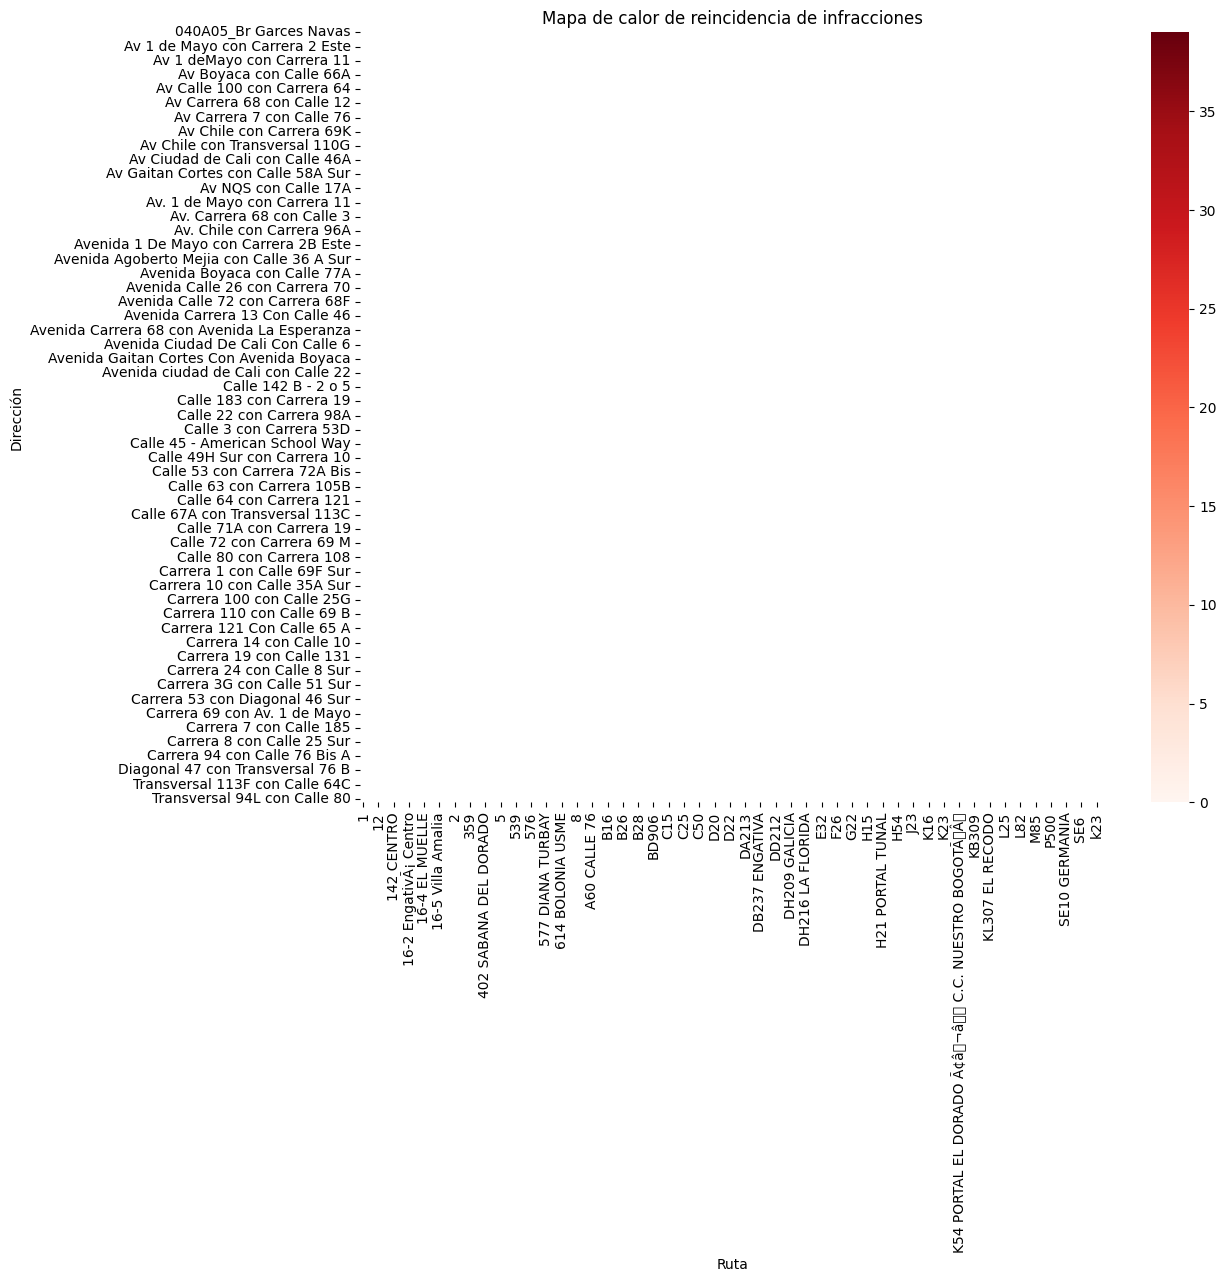

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

sns.heatmap(
    tabla_heat,
    cmap="Reds",
    linewidths=0.5
)

plt.title("Mapa de calor de reincidencia de infracciones")
plt.xlabel("Ruta")
plt.ylabel("Dirección")

plt.show()

In [52]:
ico_geo["intervalo_min"] = (
    ico_geo
    .groupby(["RUTA","DIRECCION_LIMPIA"])["hora_seg"]
    .diff()/60
)

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,hora_iden,hora_ident,hora_identif,hora_hhmm,hora_clean,hora_seg,intervalo_min,repeticion_evento,evento_seguido,cluster_evento
0,7.166176e+10,1476378,7497915.0,Int. Seguridad,2025-01-01,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,09:14,09:14,09:14,09:14,0914,33240,NaN,1.0,False,0
1,7.166176e+10,1476378,7497915.0,Int. Seguridad,2025-01-01,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,09:14,09:14,09:14,09:14,0914,33240,0.0,2.0,True,1
4,7.166176e+10,1476407,7497926.0,Int. Seguridad,2025-01-01,3/01/2025,I6012,"Manipular, tener a la mano o usar equipos elec...",10,508894,...,15:40,15:40,15:40,15:40,1540,56400,NaN,1.0,False,0
3,7.166176e+10,1476391,7497925.0,Int. Operaciones,2025-01-01,3/01/2025,I5023-3,No cumplir con los lineamientos establecidos e...,10,509117,...,14:46,14:46,14:46,14:46,1446,53160,NaN,1.0,False,0
2,7.166176e+10,1476397,7497920.0,Int. Seguridad,2025-01-01,3/01/2025,I6019-1,No portar el cinturÃ³n de seguridad o usuarlo ...,15,507967,...,12:18,12:18,12:18,12:18,1218,44280,NaN,1.0,False,0


In [53]:
intervalos = (
    ico_geo
    .groupby(["RUTA","DIRECCION_LIMPIA"])["intervalo_min"]
    .mean()
    .reset_index()
)

intervalos

,RUTA,DIRECCION_LIMPIA,intervalo_min
0,1,Av Rojas B - 1 o 5,NaN
1,1,Reportado por SP Camilo Marriaga a TC Jonier C...,NaN
2,1-1 ALAMOS,Calle 70D Bis A con Carrera 105A,NaN
3,1-1 ALAMOS,Calle 72 con Carrera 105F,NaN
4,1-1 ALAMOS,Carrera 105A con Calle 72,NaN
...,...,...,...
3360,SE6 LA ROCA,Av 1 de Mayo con Carrera 8,NaN
3361,bd237,Av Chile con Carrera 97,NaN
3362,bd237,Avenida Carrera 15 Con Calle 122,NaN
3363,k23,Av Caracas con Calle 52,NaN


In [54]:
intervalos["prob_evento"] = 1 / intervalos["intervalo_min"]

intervalos

,RUTA,DIRECCION_LIMPIA,intervalo_min,prob_evento
0,1,Av Rojas B - 1 o 5,NaN,NaN
1,1,Reportado por SP Camilo Marriaga a TC Jonier C...,NaN,NaN
2,1-1 ALAMOS,Calle 70D Bis A con Carrera 105A,NaN,NaN
3,1-1 ALAMOS,Calle 72 con Carrera 105F,NaN,NaN
4,1-1 ALAMOS,Carrera 105A con Calle 72,NaN,NaN
...,...,...,...,...
3360,SE6 LA ROCA,Av 1 de Mayo con Carrera 8,NaN,NaN
3361,bd237,Av Chile con Carrera 97,NaN,NaN
3362,bd237,Avenida Carrera 15 Con Calle 122,NaN,NaN
3363,k23,Av Caracas con Calle 52,NaN,NaN


Detección de puntos críticos

In [55]:
metricas = (
    ico_geo
    .groupby(["RUTA","DIRECCION_LIMPIA"])
    .agg(
        total_eventos=("COD_INFRACCION_TMSA","count"),
        intervalo_promedio=("intervalo_min","mean")
    )
    .reset_index()
)

In [56]:
metricas["indice_criticidad"] = (
    metricas["total_eventos"] /
    metricas["intervalo_promedio"]
)

metricas

,RUTA,DIRECCION_LIMPIA,total_eventos,intervalo_promedio,indice_criticidad
0,1,Av Rojas B - 1 o 5,1,NaN,NaN
1,1,Reportado por SP Camilo Marriaga a TC Jonier C...,1,NaN,NaN
2,1-1 ALAMOS,Calle 70D Bis A con Carrera 105A,1,NaN,NaN
3,1-1 ALAMOS,Calle 72 con Carrera 105F,1,NaN,NaN
4,1-1 ALAMOS,Carrera 105A con Calle 72,1,NaN,NaN
...,...,...,...,...,...
3360,SE6 LA ROCA,Av 1 de Mayo con Carrera 8,1,NaN,NaN
3361,bd237,Av Chile con Carrera 97,1,NaN,NaN
3362,bd237,Avenida Carrera 15 Con Calle 122,1,NaN,NaN
3363,k23,Av Caracas con Calle 52,1,NaN,NaN


In [57]:
puntos_criticos = (
    metricas
    .sort_values("indice_criticidad",ascending=False)
)

puntos_criticos

,RUTA,DIRECCION_LIMPIA,total_eventos,intervalo_promedio,indice_criticidad
2002,C101,Carrera 69 con Calle 63A,2,0.0,inf
1040,614,Avenida Caracas con Calle 65 Sur,2,0.0,inf
1064,614,Calle 19 con Carrera 69B,2,0.0,inf
3189,SE14,Calle 64 con Carrera 112C,3,0.0,inf
1050,614,Avenida caracas con Calle 65 Sur,2,0.0,inf
...,...,...,...,...,...
3360,SE6 LA ROCA,Av 1 de Mayo con Carrera 8,1,NaN,NaN
3361,bd237,Av Chile con Carrera 97,1,NaN,NaN
3362,bd237,Avenida Carrera 15 Con Calle 122,1,NaN,NaN
3363,k23,Av Caracas con Calle 52,1,NaN,NaN


Clusters

In [58]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [59]:
ico_geo.columns

Index(['ID_GMOVIL', 'ID_NOVEDAD_TMSA', 'CONSECUTIVO_INTERVENTORIA_',
       'COMPONENTE', 'FECHA__IDENTIFICACION_', 'FECHA_DE_NOTIFICACION_',
       'COD_INFRACCION_TMSA', 'DESCRIPCION', 'PUNTOS', 'COD_OPERADOR', 'MOVIL',
       'RUTA', 'DESCRIPCION_DE_NOVEDAD', 'EVIDENCIAS_', 'AREA', 'PATIO', 'ANO',
       'MES', 'DIRECCION_EXTRAIDA', 'DIRECCION_EXTRAIDA_R', 'DIRECCION_LIMPIA',
       'DIR_NORM', 'CLAVE', 'localidad', 'longitud', 'latitud', 'hora_iden',
       'hora_ident', 'hora_identif', 'hora_hhmm', 'hora_clean', 'hora_seg',
       'intervalo_min', 'repeticion_evento', 'evento_seguido',
       'cluster_evento'],
      dtype='object')

In [60]:
coords = ico_geo[["latitud","longitud"]].dropna()

In [61]:
from sklearn.cluster import DBSCAN
import numpy as np

coords_rad = np.radians(coords)

db = DBSCAN(
    eps=0.001,      # distancia aprox ~100 m
    min_samples=5   # mínimo eventos para formar cluster
).fit(coords_rad)

ico_geo.loc[coords.index,"cluster1"] = db.labels_

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,hora_ident,hora_identif,hora_hhmm,hora_clean,hora_seg,intervalo_min,repeticion_evento,evento_seguido,cluster_evento,cluster1
0,7.166176e+10,1476378,7497915.0,Int. Seguridad,2025-01-01,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,09:14,09:14,09:14,0914,33240,NaN,1.0,False,0,0.0
1,7.166176e+10,1476378,7497915.0,Int. Seguridad,2025-01-01,3/01/2025,I6019,No seguir o desconocer las instrucciones dadas...,15,503645,...,09:14,09:14,09:14,0914,33240,0.0,2.0,True,1,0.0
4,7.166176e+10,1476407,7497926.0,Int. Seguridad,2025-01-01,3/01/2025,I6012,"Manipular, tener a la mano o usar equipos elec...",10,508894,...,15:40,15:40,15:40,1540,56400,NaN,1.0,False,0,NaN
3,7.166176e+10,1476391,7497925.0,Int. Operaciones,2025-01-01,3/01/2025,I5023-3,No cumplir con los lineamientos establecidos e...,10,509117,...,14:46,14:46,14:46,1446,53160,NaN,1.0,False,0,NaN
2,7.166176e+10,1476397,7497920.0,Int. Seguridad,2025-01-01,3/01/2025,I6019-1,No portar el cinturÃ³n de seguridad o usuarlo ...,15,507967,...,12:18,12:18,12:18,1218,44280,NaN,1.0,False,0,NaN


In [62]:
hotspots = (
    ico_geo[ico_geo["cluster1"] != -1]
    .groupby("cluster1")
    .size()
    .sort_values(ascending=False)
)

hotspots

cluster1
0.0    1114
dtype: int64

In [63]:
centros = (
    ico_geo[ico_geo["cluster1"] != -1]
    .groupby("cluster1")[["latitud","longitud"]]
    .mean()
)

centros

,latitud,longitud
cluster1,,
0.0,4.623608,-74.120786


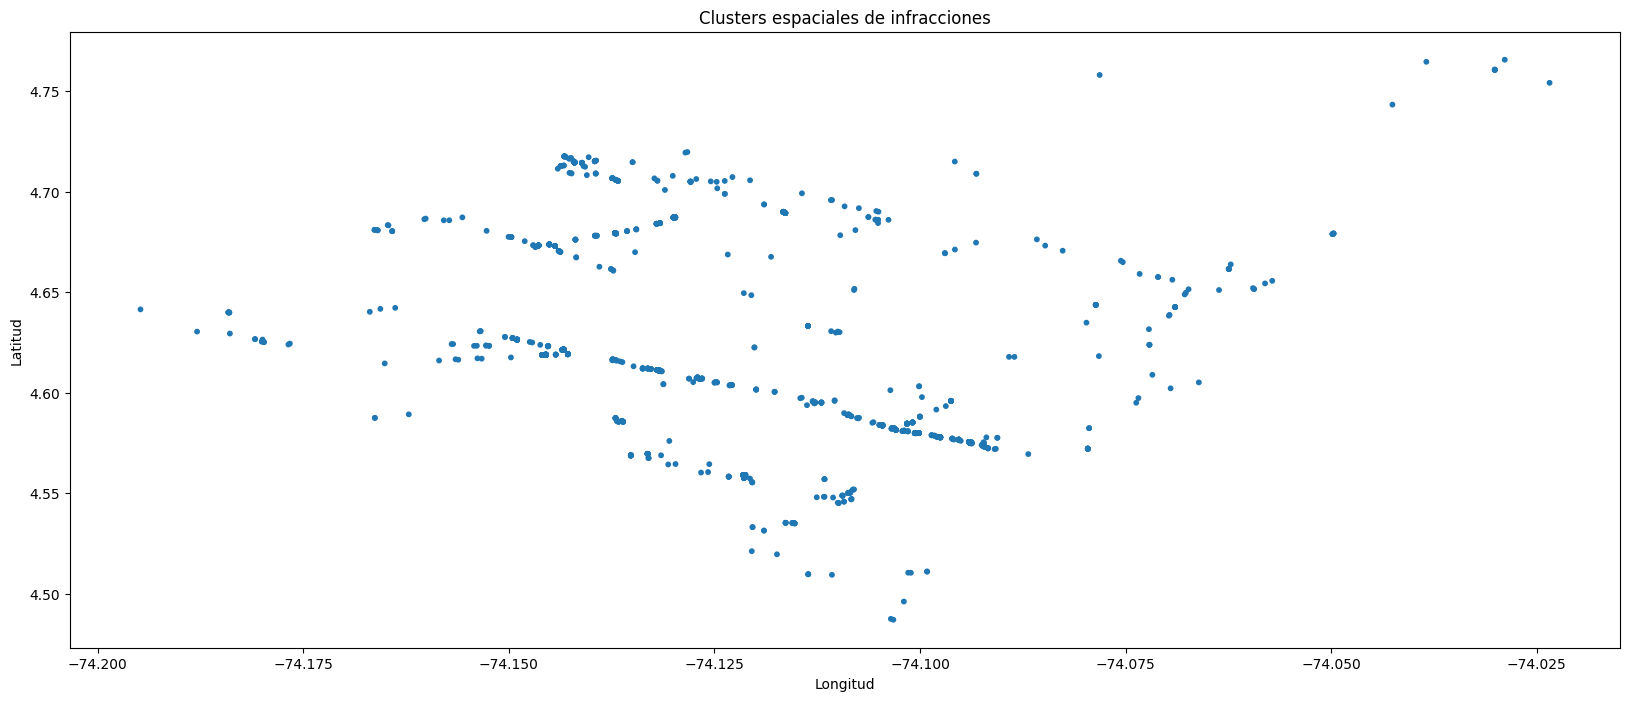

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,8))

plt.scatter(
    ico_geo["longitud"],
    ico_geo["latitud"],
    c=ico_geo["cluster1"],
    cmap="tab10",
    s=10
)

plt.title("Clusters espaciales de infracciones")
plt.xlabel("Longitud")
plt.ylabel("Latitud")

plt.show()

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

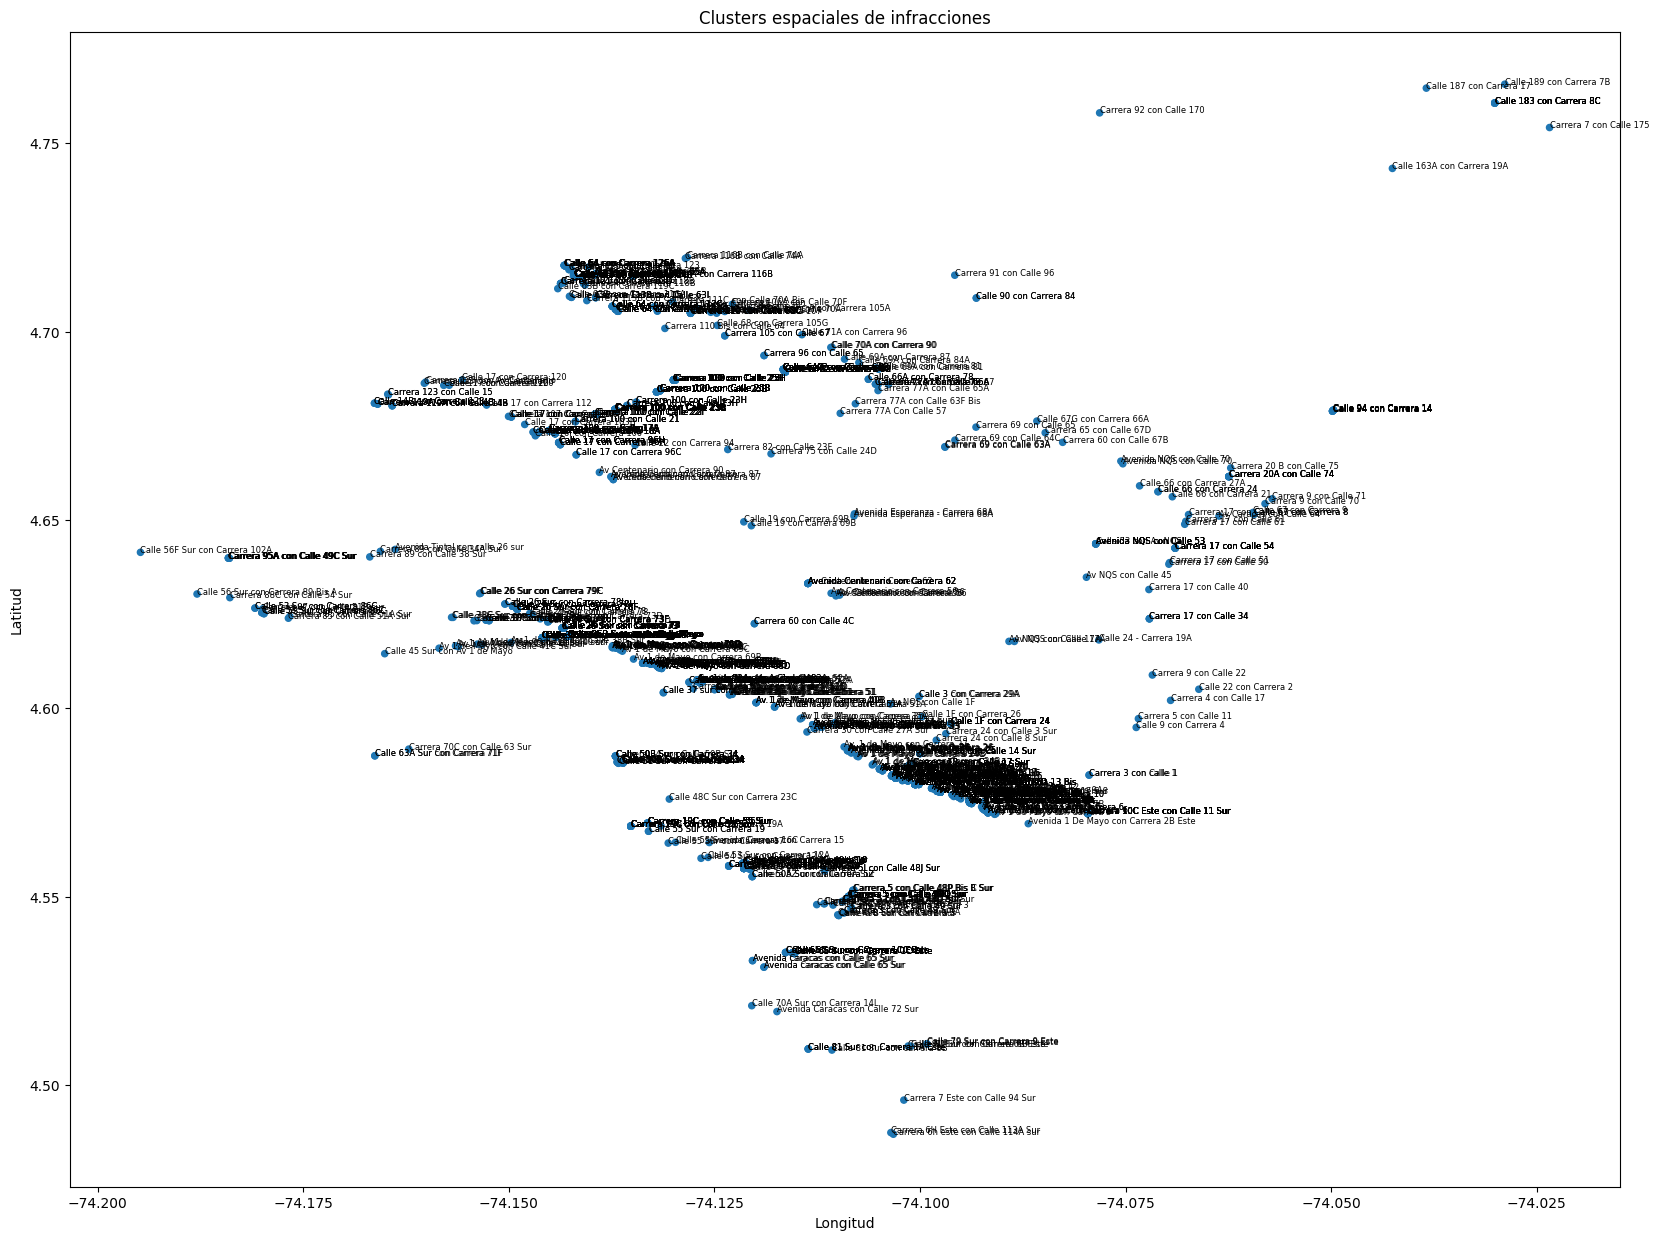

In [65]:
plt.figure(figsize=(20,15))

plt.scatter(
    ico_geo["longitud"],
    ico_geo["latitud"],
    c=ico_geo["cluster1"],
    cmap="tab10",
    s=20
)

for i, row in ico_geo.iterrows():
    plt.text(
        row["longitud"],
        row["latitud"],
        row["DIRECCION_LIMPIA"],
        fontsize=6
    )

plt.title("Clusters espaciales de infracciones")
plt.xlabel("Longitud")
plt.ylabel("Latitud")

plt.show()

In [66]:
hotspots_dir = (
    ico_geo[ico_geo["cluster1"] != -1]
    .groupby(["cluster1","DIRECCION_LIMPIA"])
    .size()
    .reset_index(name="eventos")
    .sort_values(["cluster1","eventos"],ascending=False)
)

hotspots_dir.head(20)

,cluster1,DIRECCION_LIMPIA,eventos
135,0.0,Calle 35B Sur con Av 1 de Mayo,51
13,0.0,Av 1 de Mayo con Carrera 12D,24
8,0.0,Av 1 de Mayo con Carrera 10,23
175,0.0,Calle 64G con Carrera 92,22
123,0.0,Calle 26 Sur con Carrera 73,21
136,0.0,Calle 35B Sur con Av. 1 de Mayo,18
170,0.0,Calle 64 con Carrera 112C,18
210,0.0,Carrera 100 con Calle 23B,18
213,0.0,Carrera 100 con Calle 25H,18
250,0.0,Carrera 19C con Calle 55 Sur,18


In [67]:
ico_geo.groupby(["cluster1","COD_INFRACCION_TMSA"]).size()

cluster1  COD_INFRACCION_TMSA
0.0       I5023-3                200
          I6003-1                 88
          I6011                   22
          I6012                   90
          I6017-1                  2
          I6019                  194
          I6019-1                 35
          I6019-2                 50
          I6020-1                  7
          I6024                   89
          I6025                   76
          I6026                   23
          I6029                   21
          I6032                    1
          I6035                   16
          I8006                    1
          I8007                    8
          I8007-1                 15
          I8024                  175
          M3005-04                 1
dtype: int64

In [68]:
ico_geo.groupby(["cluster1","RUTA"]).size()

cluster1  RUTA                 
0.0       1-1 ALAMOS                 1
          12                        29
          128                        1
          142                       19
          16-3 Ãlamos               2
          16-4 EL MUELLE             3
          16-5 VILLA AMALIA          1
          16-6 LA FAENA              3
          359                       18
          402                       17
          402 SABANA DEL DORADO      1
          466                       13
          539                       18
          576                       33
          577                      187
          614                      139
          740                      293
          740 ENGATIVA               1
          806                       32
          BD237                     21
          C101                      21
          C15                        1
          C25                        2
          DA213                      4
          DA218                 

In [69]:
ico_geo = ico_geo.sort_values([
    "COD_OPERADOR",
    "RUTA",
    "DIRECCION_LIMPIA",
    "COD_INFRACCION_TMSA",
    "FECHA__IDENTIFICACION_",
    "hora_seg"
])

In [70]:
ico_geo["intervalo_operador"] = (
    ico_geo
    .groupby([
        "COD_OPERADOR",
        "RUTA",
        "DIRECCION_LIMPIA",
        "COD_INFRACCION_TMSA"
    ])["hora_seg"]
    .diff() / 60
)

In [71]:
ico_geo["repeticion_operador"] = (
    ico_geo
    .groupby([
        "COD_OPERADOR",
        "RUTA",
        "DIRECCION_LIMPIA",
        "COD_INFRACCION_TMSA",
        "FECHA__IDENTIFICACION_"
    ])
    .cumcount() + 1
)

ico_geo

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,hora_hhmm,hora_clean,hora_seg,intervalo_min,repeticion_evento,evento_seguido,cluster_evento,cluster1,intervalo_operador,repeticion_operador
955,7.166176e+10,1535139,18987.0,Int. Operaciones,2025-12-04,15/04/2025,M3005-04,Transitar con exceso de velocidad,1,500025,...,12:19,1219,44340,NaN,1.0,False,0,NaN,NaN,1.0
3536,7.166176e+10,1689216,37321.0,Int. Operaciones,NaT,18/12/2025,M0007-01,"Manipular, tener a la mano o usar equipos ele...",1,500025,...,07:29,0729,26940,NaN,NaN,False,0,NaN,NaN,NaN
4541,7.166176e+10,1748507,54655.0,Int. Operaciones,NaT,24/03/2026,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,"0,5",500031,...,21:23,2123,76980,NaN,NaN,False,0,NaN,NaN,NaN
3908,7.166176e+10,1714115,44516.0,Int. Operaciones,NaT,29/01/2026,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,"0,5",500036,...,17:11,1711,61860,189.0,NaN,False,0,NaN,NaN,NaN
3475,7.166176e+10,1686170,36142.0,Int. Operaciones,2025-08-12,15/12/2025,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,0.5,500040,...,15:06,1506,54360,NaN,1.0,False,0,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4821,7.166176e+10,1763731,59778.0,Int. Operaciones,NaT,20/04/2026,I6025,Incorrecta aproximaciÃ³n a las plataformas y/o...,10,I6025,...,06:13,0613,22380,NaN,NaN,False,0,NaN,NaN,NaN
4835,7.166176e+10,1764328,59921.0,Int. Operaciones,NaT,20/04/2026,I6026,Transitar con exceso de velocidad. Nota: todo ...,15,I6026,...,16:02,1602,57720,NaN,NaN,False,0,NaN,NaN,NaN
4831,7.166176e+10,1764334,59956.0,Int. Operaciones,NaT,20/04/2026,I6026,Transitar con exceso de velocidad. Nota: todo ...,15,I6026,...,16:57,1657,61020,55.0,NaN,False,0,NaN,55.0,NaN
4833,7.166176e+10,1764332,59951.0,Int. Operaciones,NaT,20/04/2026,I6026,Transitar con exceso de velocidad. Nota: todo ...,15,I6026,...,16:45,1645,60300,NaN,NaN,False,0,NaN,NaN,NaN


In [72]:
ico_geo["evento_seguido_operador"] = (
    ico_geo["intervalo_operador"] <= 10
)

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,hora_clean,hora_seg,intervalo_min,repeticion_evento,evento_seguido,cluster_evento,cluster1,intervalo_operador,repeticion_operador,evento_seguido_operador
955,7.166176e+10,1535139,18987.0,Int. Operaciones,2025-12-04,15/04/2025,M3005-04,Transitar con exceso de velocidad,1,500025,...,1219,44340,NaN,1.0,False,0,NaN,NaN,1.0,False
3536,7.166176e+10,1689216,37321.0,Int. Operaciones,NaT,18/12/2025,M0007-01,"Manipular, tener a la mano o usar equipos ele...",1,500025,...,0729,26940,NaN,NaN,False,0,NaN,NaN,NaN,False
4541,7.166176e+10,1748507,54655.0,Int. Operaciones,NaT,24/03/2026,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,"0,5",500031,...,2123,76980,NaN,NaN,False,0,NaN,NaN,NaN,False
3908,7.166176e+10,1714115,44516.0,Int. Operaciones,NaT,29/01/2026,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,"0,5",500036,...,1711,61860,189.0,NaN,False,0,NaN,NaN,NaN,False
3475,7.166176e+10,1686170,36142.0,Int. Operaciones,2025-08-12,15/12/2025,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,0.5,500040,...,1506,54360,NaN,1.0,False,0,NaN,NaN,1.0,False


In [73]:
infracciones_operador = (
    ico_geo
    .groupby("COD_OPERADOR")
    .size()
    .sort_values(ascending=False)
)

infracciones_operador.head()

COD_OPERADOR
509240    15
509013    15
502388    14
508377    13
507546    13
dtype: int64

In [74]:
infracciones_ruta = (
    ico_geo
    .groupby(["COD_OPERADOR","RUTA"])
    .size()
    .reset_index(name="cantidad")
)

infracciones_ruta.head()

,COD_OPERADOR,RUTA,cantidad
0,500025,B23,1
1,500031,M47,1
2,500036,L25,1
3,500040,L25,1
4,500046,C15,1


In [75]:
infracciones_direccion = (
    ico_geo
    .groupby(["COD_OPERADOR","DIRECCION_LIMPIA"])
    .size()
    .reset_index(name="cantidad")
)

infracciones_direccion

,COD_OPERADOR,DIRECCION_LIMPIA,cantidad
0,500025,Av Caracas con Calle 53,1
1,500025,Av Primero de Mayo,1
2,500031,NQS - Calle 38A Sur B - 4 o 6,1
3,500036,Suba - Calle 95 B - 1 o 5,1
4,500040,Av Chile B - 2 o 5,1
...,...,...,...
4703,I6020-1,Calle 48B Sur con Carrera 20,1
4704,I6024,Carrera 24 con Calle 48B Sur,1
4705,I6025,Calle 22 Con Transversal 96B,1
4706,I6026,Carrera 17 con Calle 63B,3


In [76]:
tipo_infraccion = (
    ico_geo
    .groupby(["COD_OPERADOR","COD_INFRACCION_TMSA"])
    .size()
    .reset_index(name="cantidad")
)

tipo_infraccion

,COD_OPERADOR,COD_INFRACCION_TMSA,cantidad
0,500025,M0007-01,1
1,500025,M3005-04,1
2,500031,M1002,1
3,500036,M1002,1
4,500040,M1002,1
...,...,...,...
4015,I6020-1,I6020-1,1
4016,I6024,I6024,1
4017,I6025,I6025,1
4018,I6026,I6026,3


In [77]:
intervalo_promedio = (
    ico_geo
    .groupby(["COD_OPERADOR","COD_INFRACCION_TMSA"])
    ["intervalo_operador"]
    .mean()
    .reset_index()
)

intervalo_promedio

,COD_OPERADOR,COD_INFRACCION_TMSA,intervalo_operador
0,500025,M0007-01,NaN
1,500025,M3005-04,NaN
2,500031,M1002,NaN
3,500036,M1002,NaN
4,500040,M1002,NaN
...,...,...,...
4015,I6020-1,I6020-1,NaN
4016,I6024,I6024,NaN
4017,I6025,I6025,NaN
4018,I6026,I6026,55.0


In [78]:
metricas_operador = (
    ico_geo
    .groupby(["COD_OPERADOR","COD_INFRACCION_TMSA"])
    .agg(
        total_eventos=("COD_INFRACCION_TMSA","count"),
        intervalo_promedio=("intervalo_operador","mean")
    )
    .reset_index()
)

metricas_operador["indice_reincidencia"] = (
    metricas_operador["total_eventos"] /
    metricas_operador["intervalo_promedio"]
)

metricas_operador

,COD_OPERADOR,COD_INFRACCION_TMSA,total_eventos,intervalo_promedio,indice_reincidencia
0,500025,M0007-01,1,NaN,NaN
1,500025,M3005-04,1,NaN,NaN
2,500031,M1002,1,NaN,NaN
3,500036,M1002,1,NaN,NaN
4,500040,M1002,1,NaN,NaN
...,...,...,...,...,...
4015,I6020-1,I6020-1,1,NaN,NaN
4016,I6024,I6024,1,NaN,NaN
4017,I6025,I6025,1,NaN,NaN
4018,I6026,I6026,3,55.0,0.054545


In [79]:
ico_geo["hora_hhmm"] = (
    ico_geo["hora_hhmm"]
    .astype(str)
    .str.replace("::", ":", regex=False)   # corrige 07::10
    .str.strip()
)

In [80]:
ico_geo["hora_dt"] = pd.to_datetime(
    ico_geo["hora_hhmm"],
    format="mixed",
    errors="coerce"
)

In [81]:
def clasificar_franja(hora):

    if pd.isna(hora):
        return None

    h = hora.hour

    if 0 <= h < 6:
        return "Madrugada"
    elif 6 <= h < 10:
        return "AM Pico"
    elif 10 <= h < 13:
        return "Valle Mañana"
    elif 13 <= h < 16:
        return "Valle Tarde"
    elif 16 <= h < 20:
        return "PM Pico"
    else:
        return "Noche"

ico_geo["Franja"] = ico_geo["hora_dt"].apply(clasificar_franja)

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,intervalo_min,repeticion_evento,evento_seguido,cluster_evento,cluster1,intervalo_operador,repeticion_operador,evento_seguido_operador,hora_dt,Franja
955,7.166176e+10,1535139,18987.0,Int. Operaciones,2025-12-04,15/04/2025,M3005-04,Transitar con exceso de velocidad,1,500025,...,NaN,1.0,False,0,NaN,NaN,1.0,False,2026-06-01 12:19:00,Valle Mañana
3536,7.166176e+10,1689216,37321.0,Int. Operaciones,NaT,18/12/2025,M0007-01,"Manipular, tener a la mano o usar equipos ele...",1,500025,...,NaN,NaN,False,0,NaN,NaN,NaN,False,2026-06-01 07:29:00,AM Pico
4541,7.166176e+10,1748507,54655.0,Int. Operaciones,NaT,24/03/2026,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,"0,5",500031,...,NaN,NaN,False,0,NaN,NaN,NaN,False,2026-06-01 21:23:00,Noche
3908,7.166176e+10,1714115,44516.0,Int. Operaciones,NaT,29/01/2026,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,"0,5",500036,...,189.0,NaN,False,0,NaN,NaN,NaN,False,2026-06-01 17:11:00,PM Pico
3475,7.166176e+10,1686170,36142.0,Int. Operaciones,2025-08-12,15/12/2025,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,0.5,500040,...,NaN,1.0,False,0,NaN,NaN,1.0,False,2026-06-01 15:06:00,Valle Tarde


In [82]:
patrones = (
    ico_geo
    .groupby([
        "COD_OPERADOR",
        "FECHA__IDENTIFICACION_",
        "COD_INFRACCION_TMSA",
        "DESCRIPCION",
        "DIRECCION_LIMPIA",
        "Franja"
    ])
    .size()
    .reset_index(name="Cantidad")
)

patrones

,COD_OPERADOR,FECHA__IDENTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,DIRECCION_LIMPIA,Franja,Cantidad
0,500025,2025-12-04,M3005-04,Transitar con exceso de velocidad,Av Caracas con Calle 53,Valle Mañana,1
1,500040,2025-08-12,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,Av Chile B - 2 o 5,Valle Tarde,1
2,500083,2025-02-04,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,Av. 1 de Mayo B - 4 o 6,Valle Mañana,1
3,500105,2025-07-02,M0021,No cumplir con los lineamientos u obligaciones...,Autopista Norte con Calle 176,AM Pico,1
4,500107,2025-12-05,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,Suba - Calle 95 B - 1 o 5,Valle Mañana,1
...,...,...,...,...,...,...,...
1780,510526,2026-12-05,I6019,No seguir o desconocer las instrucciones dadas...,Av Carrera 68 con Calle 4D,Valle Tarde,1
1781,510572,2026-07-05,I6011,Alterar el recorrido de un servicio sin la pre...,Avenida Carrera 28 con Calle 37,PM Pico,1
1782,510574,2026-08-05,I6026,Transitar con exceso de velocidad. Nota: todo ...,Calle 63 con Transversal 59A,AM Pico,1
1783,510616,2026-11-05,I6019,No seguir o desconocer las instrucciones dadas...,Carrera 21 con Calle 13A Sur,Valle Mañana,1


In [83]:
reincidentes = patrones[patrones["Cantidad"] > 1]

reincidentes.head()

,COD_OPERADOR,FECHA__IDENTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,DIRECCION_LIMPIA,Franja,Cantidad
42,501243,2026-05-02,I6019-2,Omitir o realizar de forma indebida el PARE,Calle 49H Sur con Carrera 10,AM Pico,2
44,501243,2026-10-03,I5023-3,No cumplir con los lineamientos establecidos e...,Avenida 1 de Mayo con Carrera 6,Valle Tarde,2
64,501603,2025-12-06,I6019-2,Omitir o realizar de forma indebida el PARE,Calle 18 con Carrera 27,Valle Tarde,2
100,502388,2025-04-06,I6019,No seguir o desconocer las instrucciones dadas...,Calle 35B Sur con Av 1 de Mayo,PM Pico,3
125,503033,2026-01-01,I8024,No aplicar manejo preventivo.,Av 1 de Mayo con Carrera 51D,AM Pico,3


In [84]:
operador_patrones = (
    ico_geo
    .groupby([
        "COD_OPERADOR",
        "COD_INFRACCION_TMSA",
        "DESCRIPCION",
        "DIRECCION_LIMPIA",
        "Franja"
    ])
    .size()
    .reset_index(name="Total")
    .sort_values("Total", ascending=False)
)

operador_patrones.head()

,COD_OPERADOR,COD_INFRACCION_TMSA,DESCRIPCION,DIRECCION_LIMPIA,Franja,Total
2238,509013,I8024,No aplicar manejo preventivo.,Calle 35B Sur con Av 1 de Mayo,AM Pico,6
1592,508377,I5023-3,No cumplir con los lineamientos establecidos e...,Calle 65 Sur con Carrera 1C Este,PM Pico,6
4287,510162,I6024,Pasar el semÃ¡foro en rojo.,Calle 35B Sur con Av 1 de Mayo,AM Pico,6
2833,509442,I6025,Incorrecta aproximaciÃ³n a las plataformas y/o...,Av 1 de Mayo con Carrera 24B,PM Pico,4
3500,509753,I6019,No seguir o desconocer las instrucciones dadas...,Av 1 de Mayo con Carrera 51,Valle Tarde,4


In [85]:
ico_geo = ico_geo.sort_values([
    "COD_OPERADOR",
    "COD_INFRACCION_TMSA",
    "DESCRIPCION",
    "DIRECCION_LIMPIA",
    "FECHA__IDENTIFICACION_",
    "hora_seg"
])

In [86]:
ico_geo["intervalo_infraccion"] = (
    ico_geo
    .groupby([
        "COD_OPERADOR",
        "COD_INFRACCION_TMSA",
        "DIRECCION_LIMPIA"
    ])["hora_seg"]
    .diff()
)

ico_geo.head()

,ID_GMOVIL,ID_NOVEDAD_TMSA,CONSECUTIVO_INTERVENTORIA_,COMPONENTE,FECHA__IDENTIFICACION_,FECHA_DE_NOTIFICACION_,COD_INFRACCION_TMSA,DESCRIPCION,PUNTOS,COD_OPERADOR,...,repeticion_evento,evento_seguido,cluster_evento,cluster1,intervalo_operador,repeticion_operador,evento_seguido_operador,hora_dt,Franja,intervalo_infraccion
3536,7.166176e+10,1689216,37321.0,Int. Operaciones,NaT,18/12/2025,M0007-01,"Manipular, tener a la mano o usar equipos ele...",1,500025,...,NaN,False,0,NaN,NaN,NaN,False,2026-06-01 07:29:00,AM Pico,NaN
955,7.166176e+10,1535139,18987.0,Int. Operaciones,2025-12-04,15/04/2025,M3005-04,Transitar con exceso de velocidad,1,500025,...,1.0,False,0,NaN,NaN,1.0,False,2026-06-01 12:19:00,Valle Mañana,NaN
4541,7.166176e+10,1748507,54655.0,Int. Operaciones,NaT,24/03/2026,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,"0,5",500031,...,NaN,False,0,NaN,NaN,NaN,False,2026-06-01 21:23:00,Noche,NaN
3908,7.166176e+10,1714115,44516.0,Int. Operaciones,NaT,29/01/2026,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,"0,5",500036,...,NaN,False,0,NaN,NaN,NaN,False,2026-06-01 17:11:00,PM Pico,NaN
3475,7.166176e+10,1686170,36142.0,Int. Operaciones,2025-08-12,15/12/2025,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,0.5,500040,...,1.0,False,0,NaN,NaN,1.0,False,2026-06-01 15:06:00,Valle Tarde,NaN


In [87]:
patron_dominante = (
    operador_patrones
    .groupby("COD_OPERADOR")
    .first()
    .reset_index()
)

patron_dominante

,COD_OPERADOR,COD_INFRACCION_TMSA,DESCRIPCION,DIRECCION_LIMPIA,Franja,Total
0,500025,M0007-01,"Manipular, tener a la mano o usar equipos ele...",Av Primero de Mayo,AM Pico,1
1,500031,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,NQS - Calle 38A Sur B - 4 o 6,Noche,1
2,500036,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,Suba - Calle 95 B - 1 o 5,PM Pico,1
3,500040,M1002,NoÂ pararÂ enÂ unaÂ estaciÃ³nÂ establecidaÂ en...,Av Chile B - 2 o 5,Valle Tarde,1
4,500046,M3005,NoÂ cumplirÂ conÂ laÂ realizaciÃ³nÂ delÂ PlanÂ...,Niza - Calle 127,Valle Tarde,1
...,...,...,...,...,...,...
1848,I6020-1,I6020-1,"Omitir, negarse y/o brindar informaciÃ³n opera...",Calle 48B Sur con Carrera 20,PM Pico,1
1849,I6024,I6024,Pasar el semÃ¡foro en rojo.,Carrera 24 con Calle 48B Sur,AM Pico,1
1850,I6025,I6025,Incorrecta aproximaciÃ³n a las plataformas y/o...,Calle 22 Con Transversal 96B,AM Pico,1
1851,I6026,I6026,Transitar con exceso de velocidad. Nota: todo ...,Carrera 17 con Calle 63B,PM Pico,3


In [88]:
tabla = (
    ico_geo
    .groupby(["COD_OPERADOR","Franja"])
    .size()
    .unstack(fill_value=0)
)

tabla

Franja,AM Pico,Madrugada,Noche,PM Pico,Valle Mañana,Valle Tarde
COD_OPERADOR,,,,,,
500025,1,0,0,0,1,0
500031,0,0,1,0,0,0
500036,0,0,0,1,0,0
500040,0,0,0,0,0,1
500046,0,0,0,0,0,1
...,...,...,...,...,...,...
I6020-1,0,0,0,1,0,0
I6024,1,0,0,0,0,0
I6025,1,0,0,0,0,0


In [89]:
total_operador = (
    ico_geo
    .groupby("COD_OPERADOR")
    .size()
    .reset_index(name="total_infracciones")
)

total_operador

,COD_OPERADOR,total_infracciones
0,500025,2
1,500031,1
2,500036,1
3,500040,1
4,500046,1
...,...,...
1860,I6020-1,1
1861,I6024,1
1862,I6025,1
1863,I6026,3


In [90]:
repeticiones = (
    ico_geo
    .groupby([
        "COD_OPERADOR",
        "FECHA__IDENTIFICACION_",
        "COD_INFRACCION_TMSA",
        "DIRECCION_LIMPIA",
        "Franja"
    ])
    .size()
    .reset_index(name="conteo")
)

repeticiones 

,COD_OPERADOR,FECHA__IDENTIFICACION_,COD_INFRACCION_TMSA,DIRECCION_LIMPIA,Franja,conteo
0,500025,2025-12-04,M3005-04,Av Caracas con Calle 53,Valle Mañana,1
1,500040,2025-08-12,M1002,Av Chile B - 2 o 5,Valle Tarde,1
2,500083,2025-02-04,M1002,Av. 1 de Mayo B - 4 o 6,Valle Mañana,1
3,500105,2025-07-02,M0021,Autopista Norte con Calle 176,AM Pico,1
4,500107,2025-12-05,M1002,Suba - Calle 95 B - 1 o 5,Valle Mañana,1
...,...,...,...,...,...,...
1780,510526,2026-12-05,I6019,Av Carrera 68 con Calle 4D,Valle Tarde,1
1781,510572,2026-07-05,I6011,Avenida Carrera 28 con Calle 37,PM Pico,1
1782,510574,2026-08-05,I6026,Calle 63 con Transversal 59A,AM Pico,1
1783,510616,2026-11-05,I6019,Carrera 21 con Calle 13A Sur,Valle Mañana,1


In [91]:
repeticiones_reales = repeticiones[repeticiones["conteo"] > 1]

In [92]:
rep_operador = (
    repeticiones_reales
    .groupby("COD_OPERADOR")["conteo"]
    .sum()
    .reset_index(name="infracciones_repetidas")
)

rep_operador

,COD_OPERADOR,infracciones_repetidas
0,501243,4
1,501603,2
2,502388,3
3,503033,3
4,503645,2
...,...,...
97,510233,2
98,510277,3
99,510289,2
100,510307,2


In [93]:
indice_reincidencia = total_operador.merge(
    rep_operador,
    on="COD_OPERADOR",
    how="left"
)

indice_reincidencia["infracciones_repetidas"] = (
    indice_reincidencia["infracciones_repetidas"].fillna(0)
)

indice_reincidencia["indice_reincidencia"] = (
    indice_reincidencia["infracciones_repetidas"] /
    indice_reincidencia["total_infracciones"]
)

indice_reincidencia.head()

,COD_OPERADOR,total_infracciones,infracciones_repetidas,indice_reincidencia
0,500025,2,0.0,0.0
1,500031,1,0.0,0.0
2,500036,1,0.0,0.0
3,500040,1,0.0,0.0
4,500046,1,0.0,0.0


In [94]:
def clasificar_indice(x):

    if x < 0.10:
        return "🟢 Normal"

    elif x < 0.30:
        return "🟡 Reincidencia moderada"

    else:
        return "🔴 Reincidencia crítica"

indice_reincidencia["clasificacion"] = (
    indice_reincidencia["indice_reincidencia"]
    .apply(clasificar_indice)
)

indice_reincidencia.head()

,COD_OPERADOR,total_infracciones,infracciones_repetidas,indice_reincidencia,clasificacion
0,500025,2,0.0,0.0,🟢 Normal
1,500031,1,0.0,0.0,🟢 Normal
2,500036,1,0.0,0.0,🟢 Normal
3,500040,1,0.0,0.0,🟢 Normal
4,500046,1,0.0,0.0,🟢 Normal


In [95]:
indice_reincidencia.sort_values(
    "indice_reincidencia",
    ascending=False
)

,COD_OPERADOR,total_infracciones,infracciones_repetidas,indice_reincidencia,clasificacion
1452,509937,2,2.0,1.0,🔴 Reincidencia crítica
1581,510105,2,2.0,1.0,🔴 Reincidencia crítica
1303,509727,2,2.0,1.0,🔴 Reincidencia crítica
1660,510211,2,2.0,1.0,🔴 Reincidencia crítica
752,508585,3,3.0,1.0,🔴 Reincidencia crítica
...,...,...,...,...,...
626,508077,3,0.0,0.0,🟢 Normal
625,508076,7,0.0,0.0,🟢 Normal
624,508075,3,0.0,0.0,🟢 Normal
623,508070,8,0.0,0.0,🟢 Normal


In [96]:
total_operador = (
    ico_geo
    .groupby(["COD_OPERADOR","COD_INFRACCION_TMSA"])
    .size()
    .reset_index(name="total_infracciones")
)

In [97]:
repeticiones = (
    ico_geo
    .groupby([
        "COD_OPERADOR",
        "COD_INFRACCION_TMSA",
        "FECHA__IDENTIFICACION_",
        "DIRECCION_LIMPIA",
        "Franja"
    ])
    .size()
    .reset_index(name="conteo")
)

In [98]:
repeticiones_reales = repeticiones[repeticiones["conteo"] > 1]

In [99]:
rep_operador = (
    repeticiones_reales
    .groupby(["COD_OPERADOR","COD_INFRACCION_TMSA"])["conteo"]
    .sum()
    .reset_index(name="infracciones_repetidas")
)


In [100]:
indice_reincidencia = total_operador.merge(
    rep_operador,
    on=["COD_OPERADOR","COD_INFRACCION_TMSA"],
    how="left"
)

indice_reincidencia["infracciones_repetidas"] = (
    indice_reincidencia["infracciones_repetidas"].fillna(0)
)

indice_reincidencia["indice_reincidencia"] = (
    indice_reincidencia["infracciones_repetidas"] /
    indice_reincidencia["total_infracciones"]
)

In [101]:
def clasificar_indice(x):

    if x < 0.10:
        return "🟢 Normal"
    elif x < 0.30:
        return "🟡 Reincidencia moderada"
    else:
        return "🔴 Reincidencia crítica"

indice_reincidencia["clasificacion"] = (
    indice_reincidencia["indice_reincidencia"]
    .apply(clasificar_indice)
)

indice_reincidencia.head()

,COD_OPERADOR,COD_INFRACCION_TMSA,total_infracciones,infracciones_repetidas,indice_reincidencia,clasificacion
0,500025,M0007-01,1,0.0,0.0,🟢 Normal
1,500025,M3005-04,1,0.0,0.0,🟢 Normal
2,500031,M1002,1,0.0,0.0,🟢 Normal
3,500036,M1002,1,0.0,0.0,🟢 Normal
4,500040,M1002,1,0.0,0.0,🟢 Normal


In [102]:
indice_reincidencia.sort_values(
    "indice_reincidencia",
    ascending=False
)

,COD_OPERADOR,COD_INFRACCION_TMSA,total_infracciones,infracciones_repetidas,indice_reincidencia,clasificacion
1535,508644,I6019-2,3,3.0,1.0,🔴 Reincidencia crítica
3699,510206,I6035,2,2.0,1.0,🔴 Reincidencia crítica
3814,510307,I6011,2,2.0,1.0,🔴 Reincidencia crítica
2595,509555,I6025,2,2.0,1.0,🔴 Reincidencia crítica
2487,509505,I6012,3,3.0,1.0,🔴 Reincidencia crítica
...,...,...,...,...,...,...
1354,508343,I6025,1,0.0,0.0,🟢 Normal
1355,508366,I5023-3,1,0.0,0.0,🟢 Normal
1356,508366,I6012,2,0.0,0.0,🟢 Normal
1357,508367,I5023-3,2,0.0,0.0,🟢 Normal


In [103]:
ico_geo.to_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/ICO/seguimiento_ICO_geo.csv', sep=';', index=False)

In [104]:
ico.to_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/ICO/seguimiento_ICO.csv', sep=';', index=False)

In [105]:
indice_reincidencia.to_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2026/ICO/operadores_reincidentes.csv', sep=';', index=False)